# Automatically generating object masks with SAM

Since SAM can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image. This method was used to generate the dataset SA-1B.

The class `SamAutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

## Environment Set-up

If running locally using jupyter, first install `segment_anything` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything#installation) in the repository. If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install --upgrade torch torchvision
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
print("Mac M1+ Metal is available:", torch.backends.mps.is_available())
print("MKL is available:", torch.backends.mkl.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

!mkdir images

#!curl -o sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.3.1
Torchvision version: 0.18.1
CUDA is available: False
Mac M1+ Metal is available: True
MKL is available: False
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-k9egqmxu
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-k9egqmxu
^C
ERROR: Operation cancelled by user
mkdir: images: File exists


## Set-up

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [3]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

## Example image

In [67]:
image = cv2.imread('images/test02.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

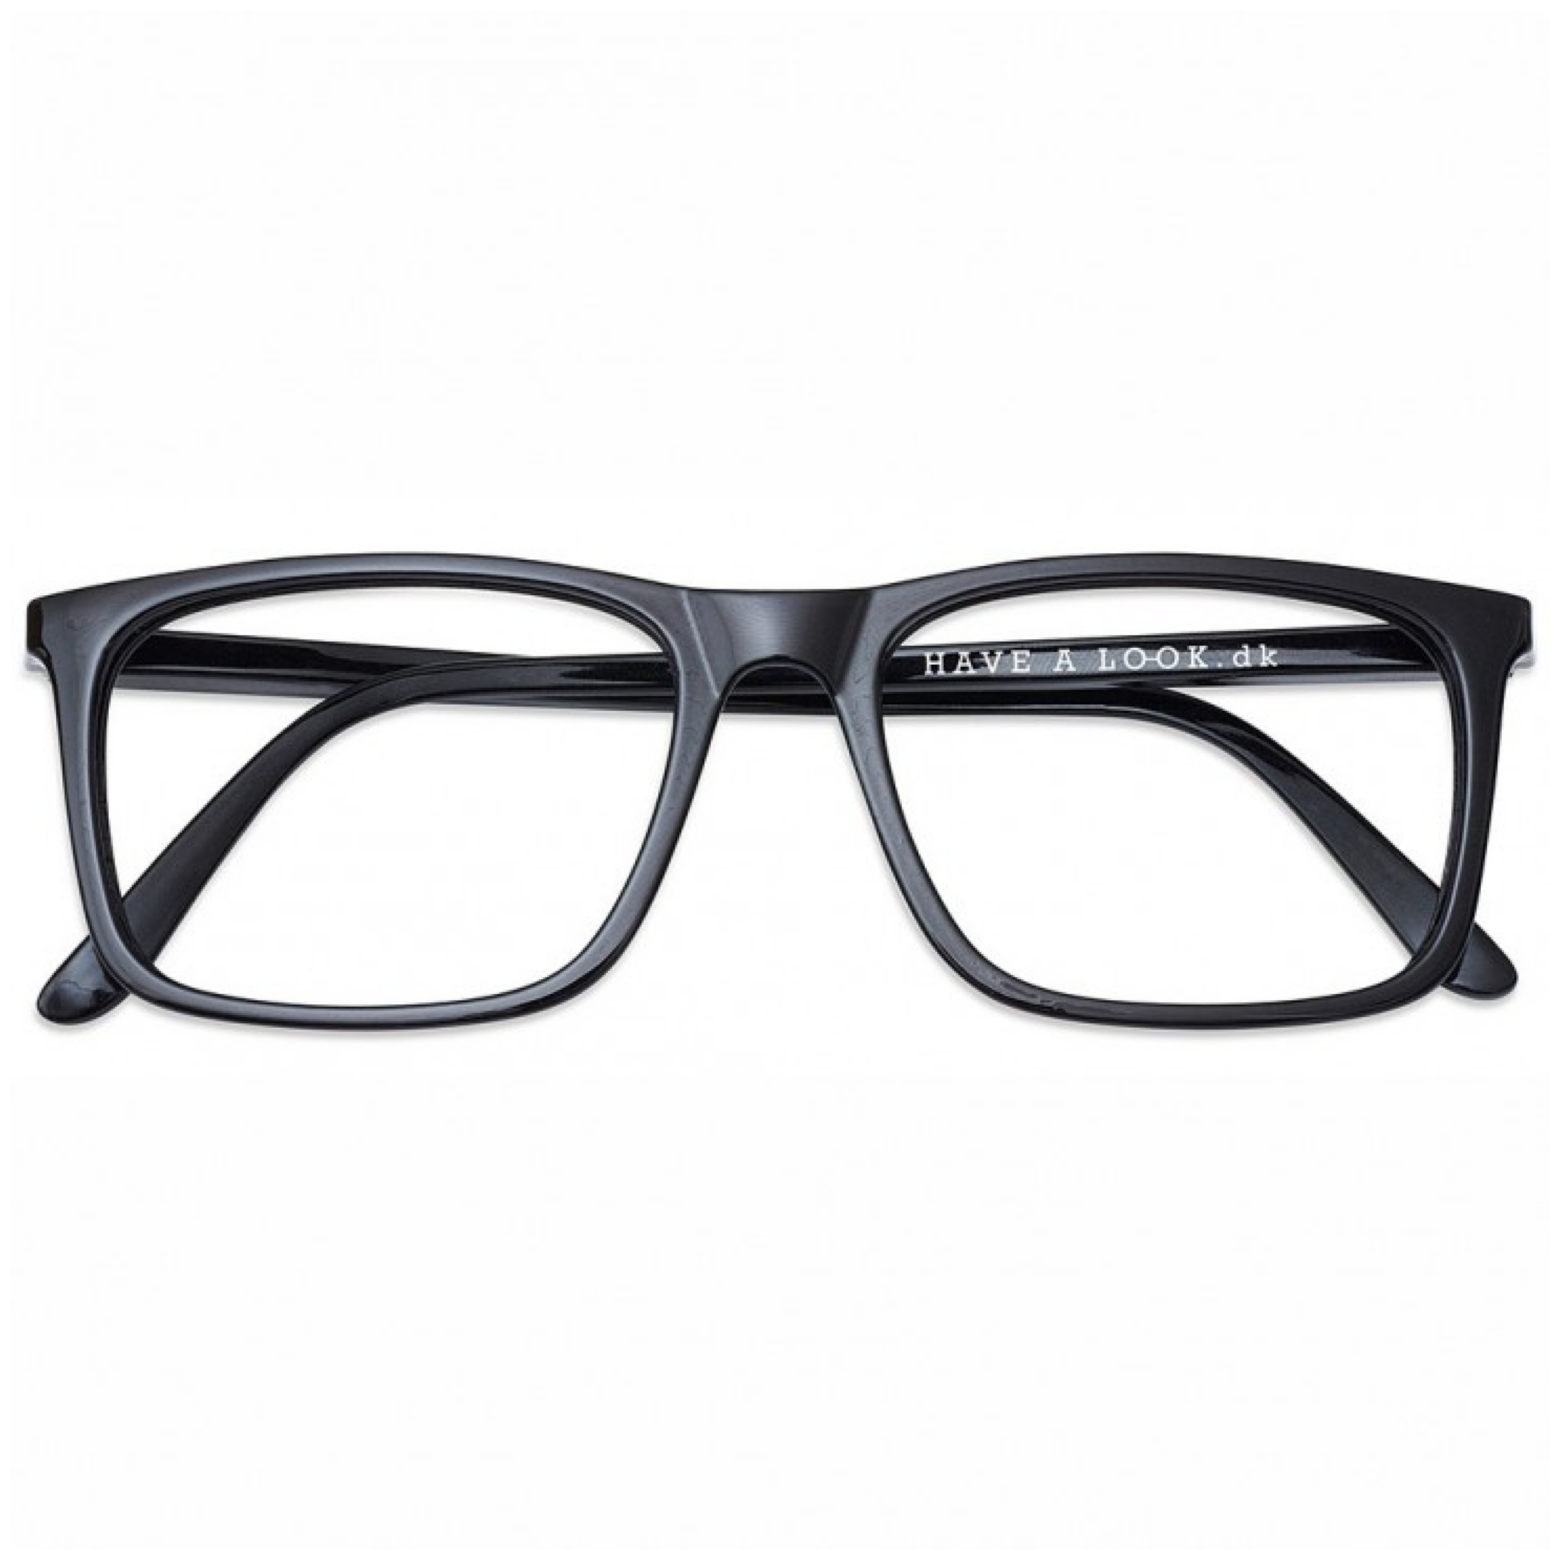

In [68]:
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Automatic mask generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [69]:
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [70]:
masks = mask_generator.generate(image)

In [71]:
print(len(masks))
print(masks[0].keys())

13
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


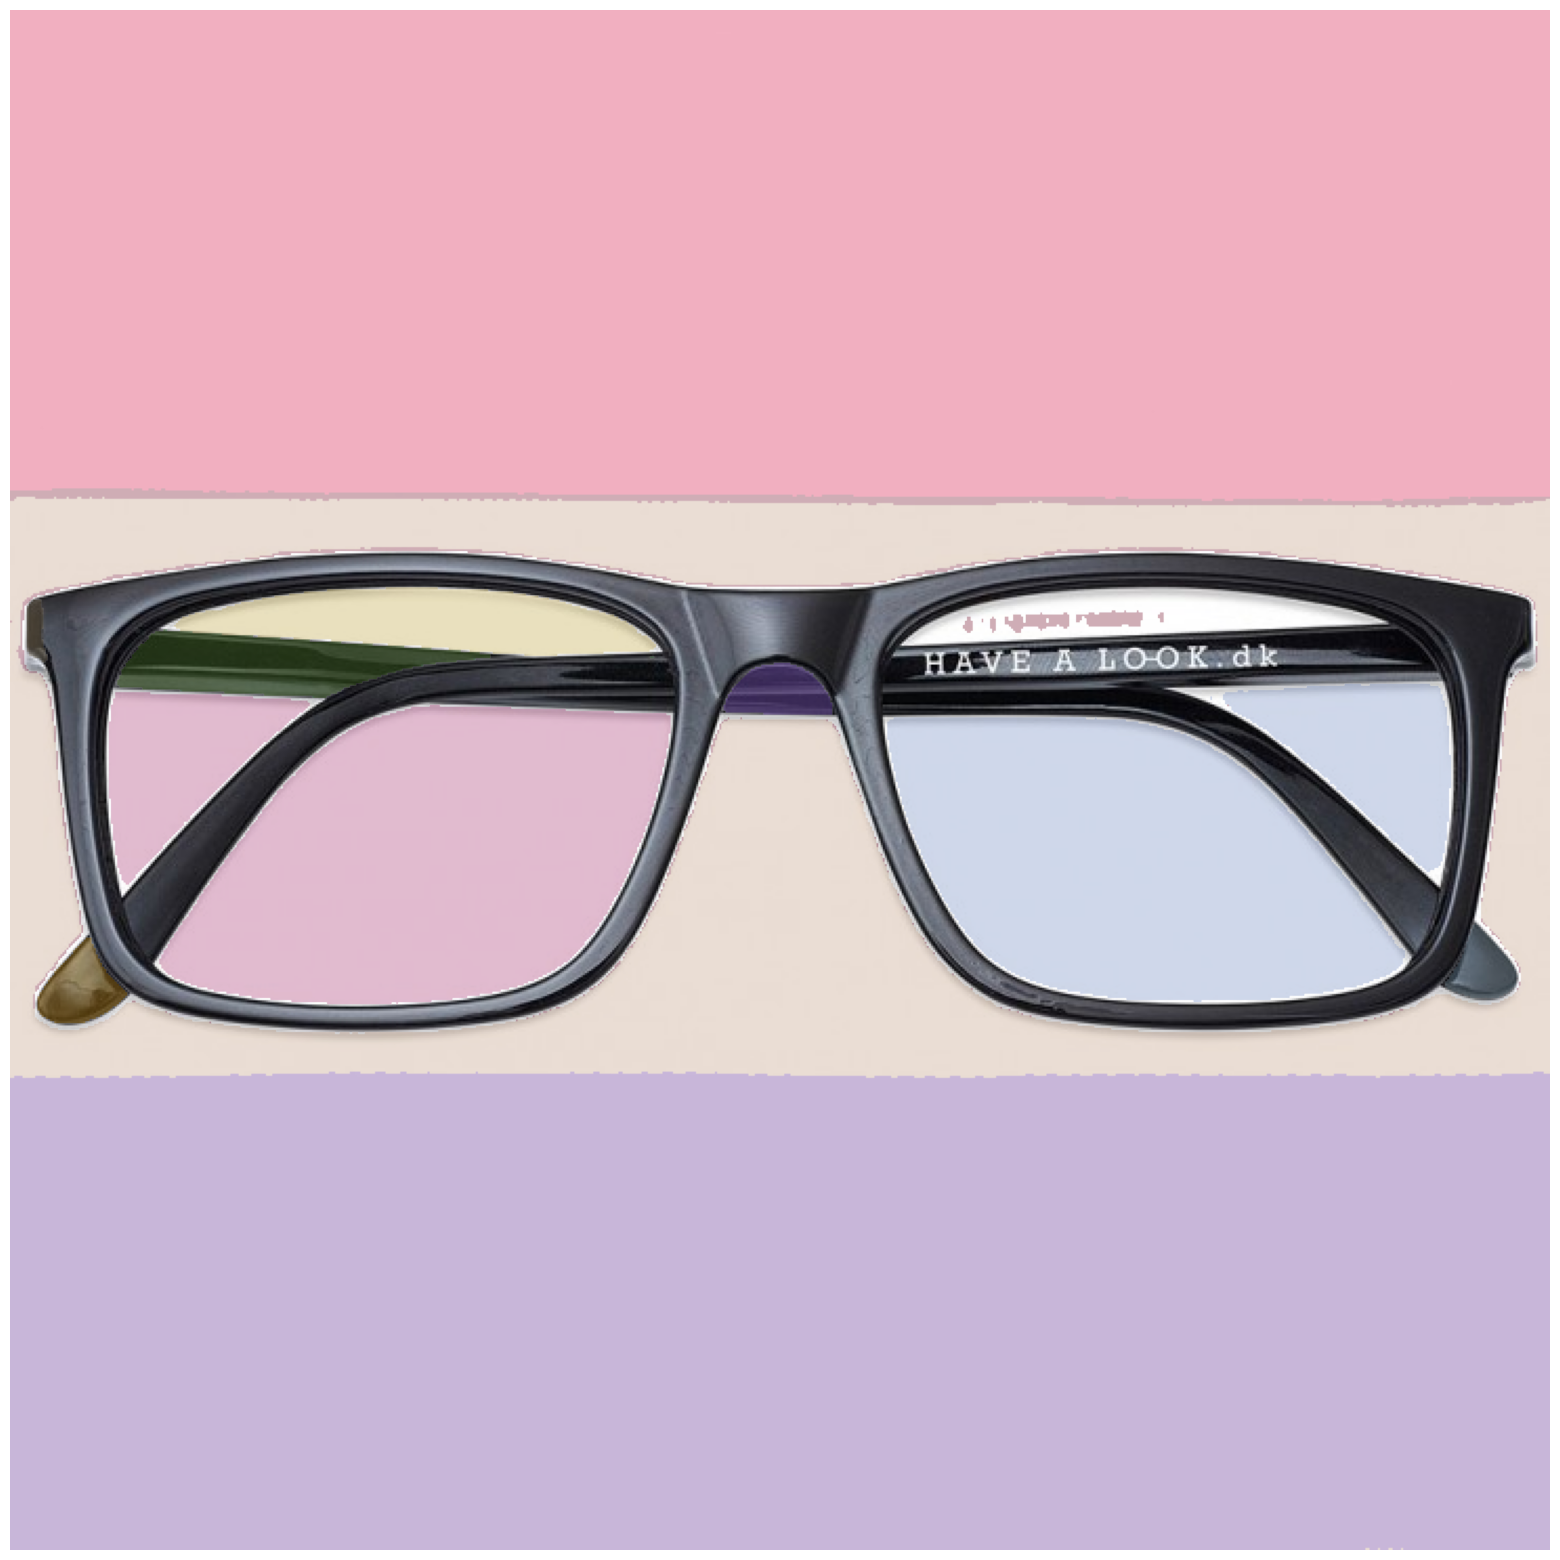

In [72]:
# display detected masks

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

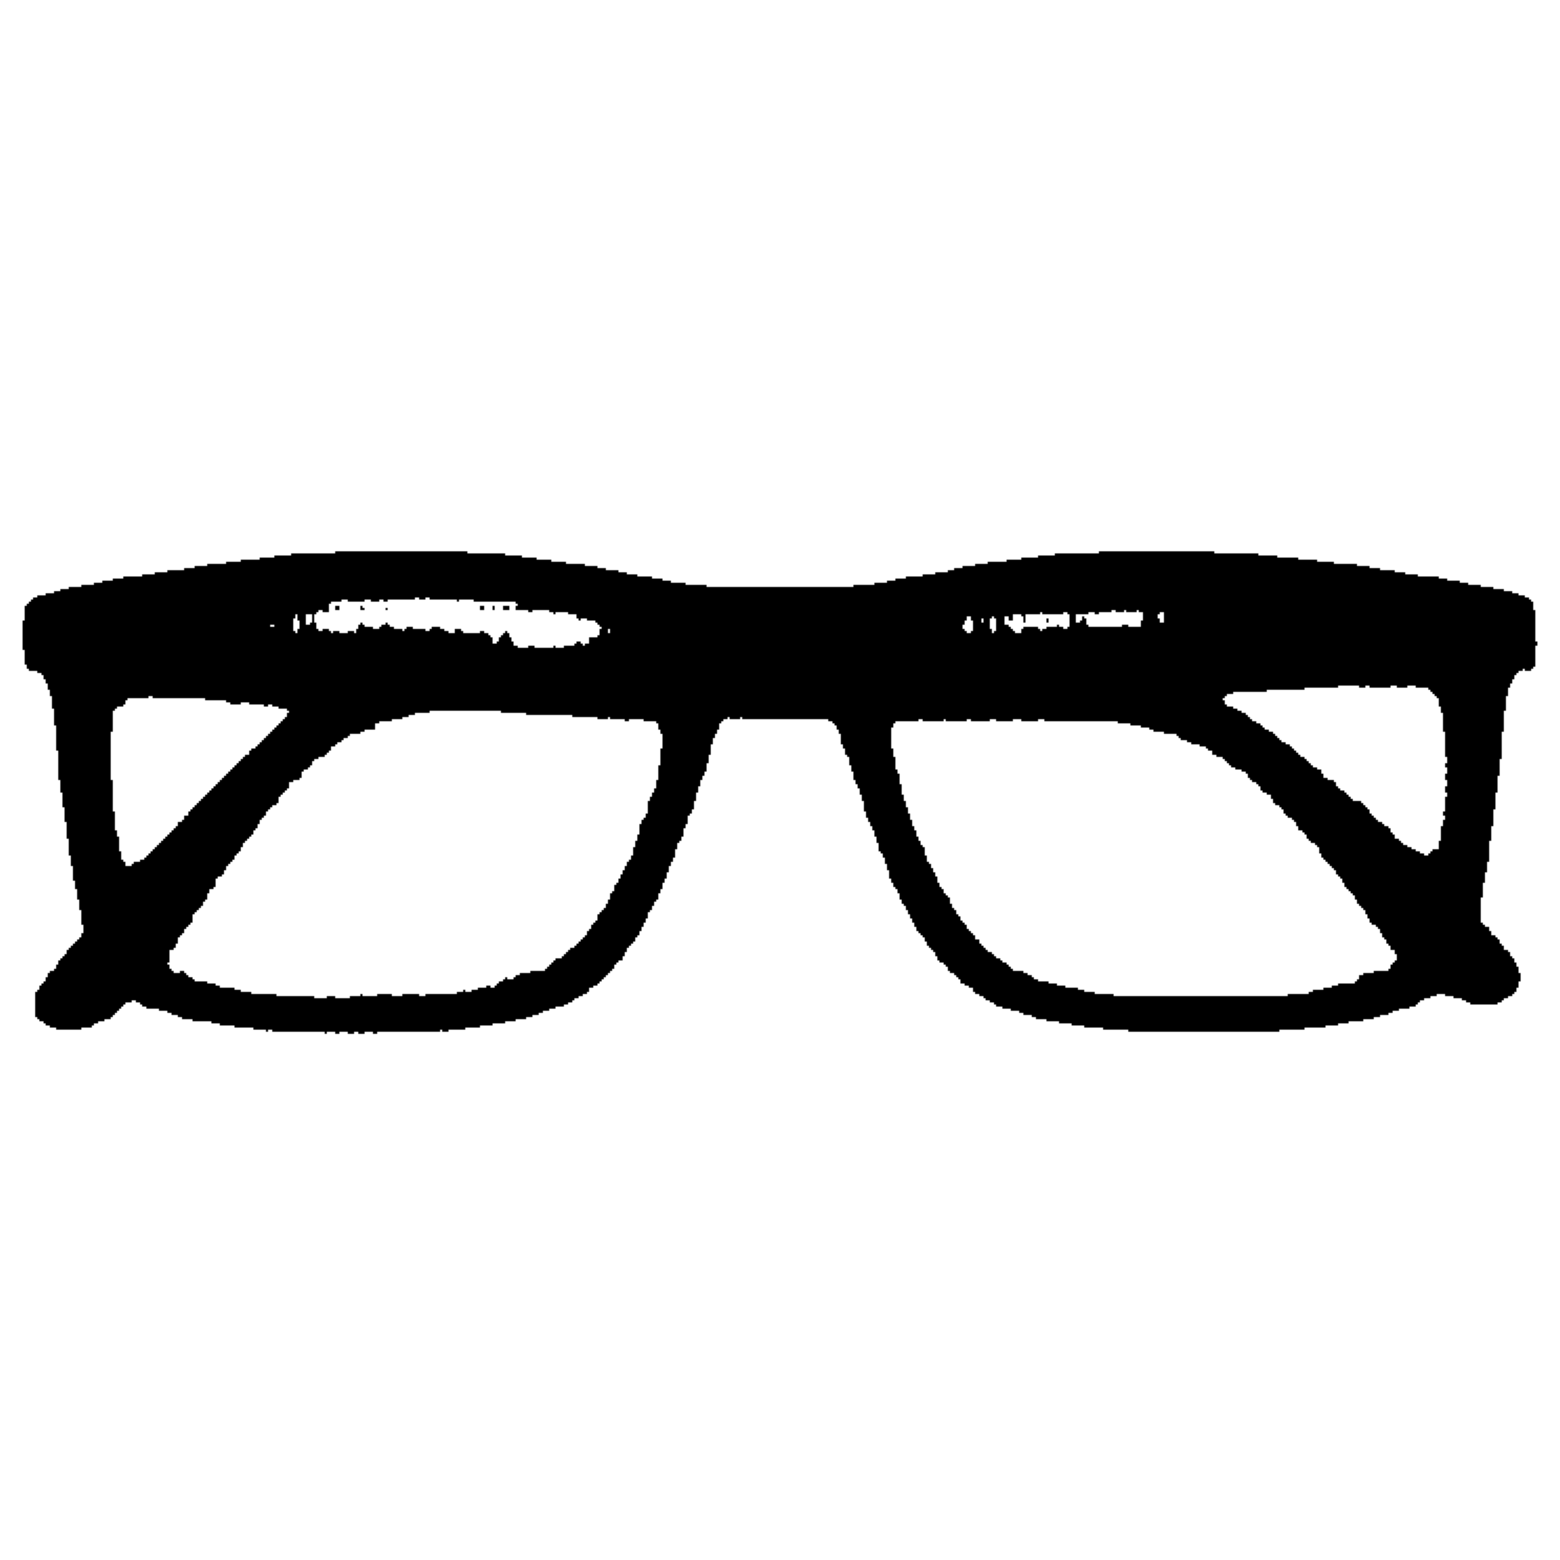

462032


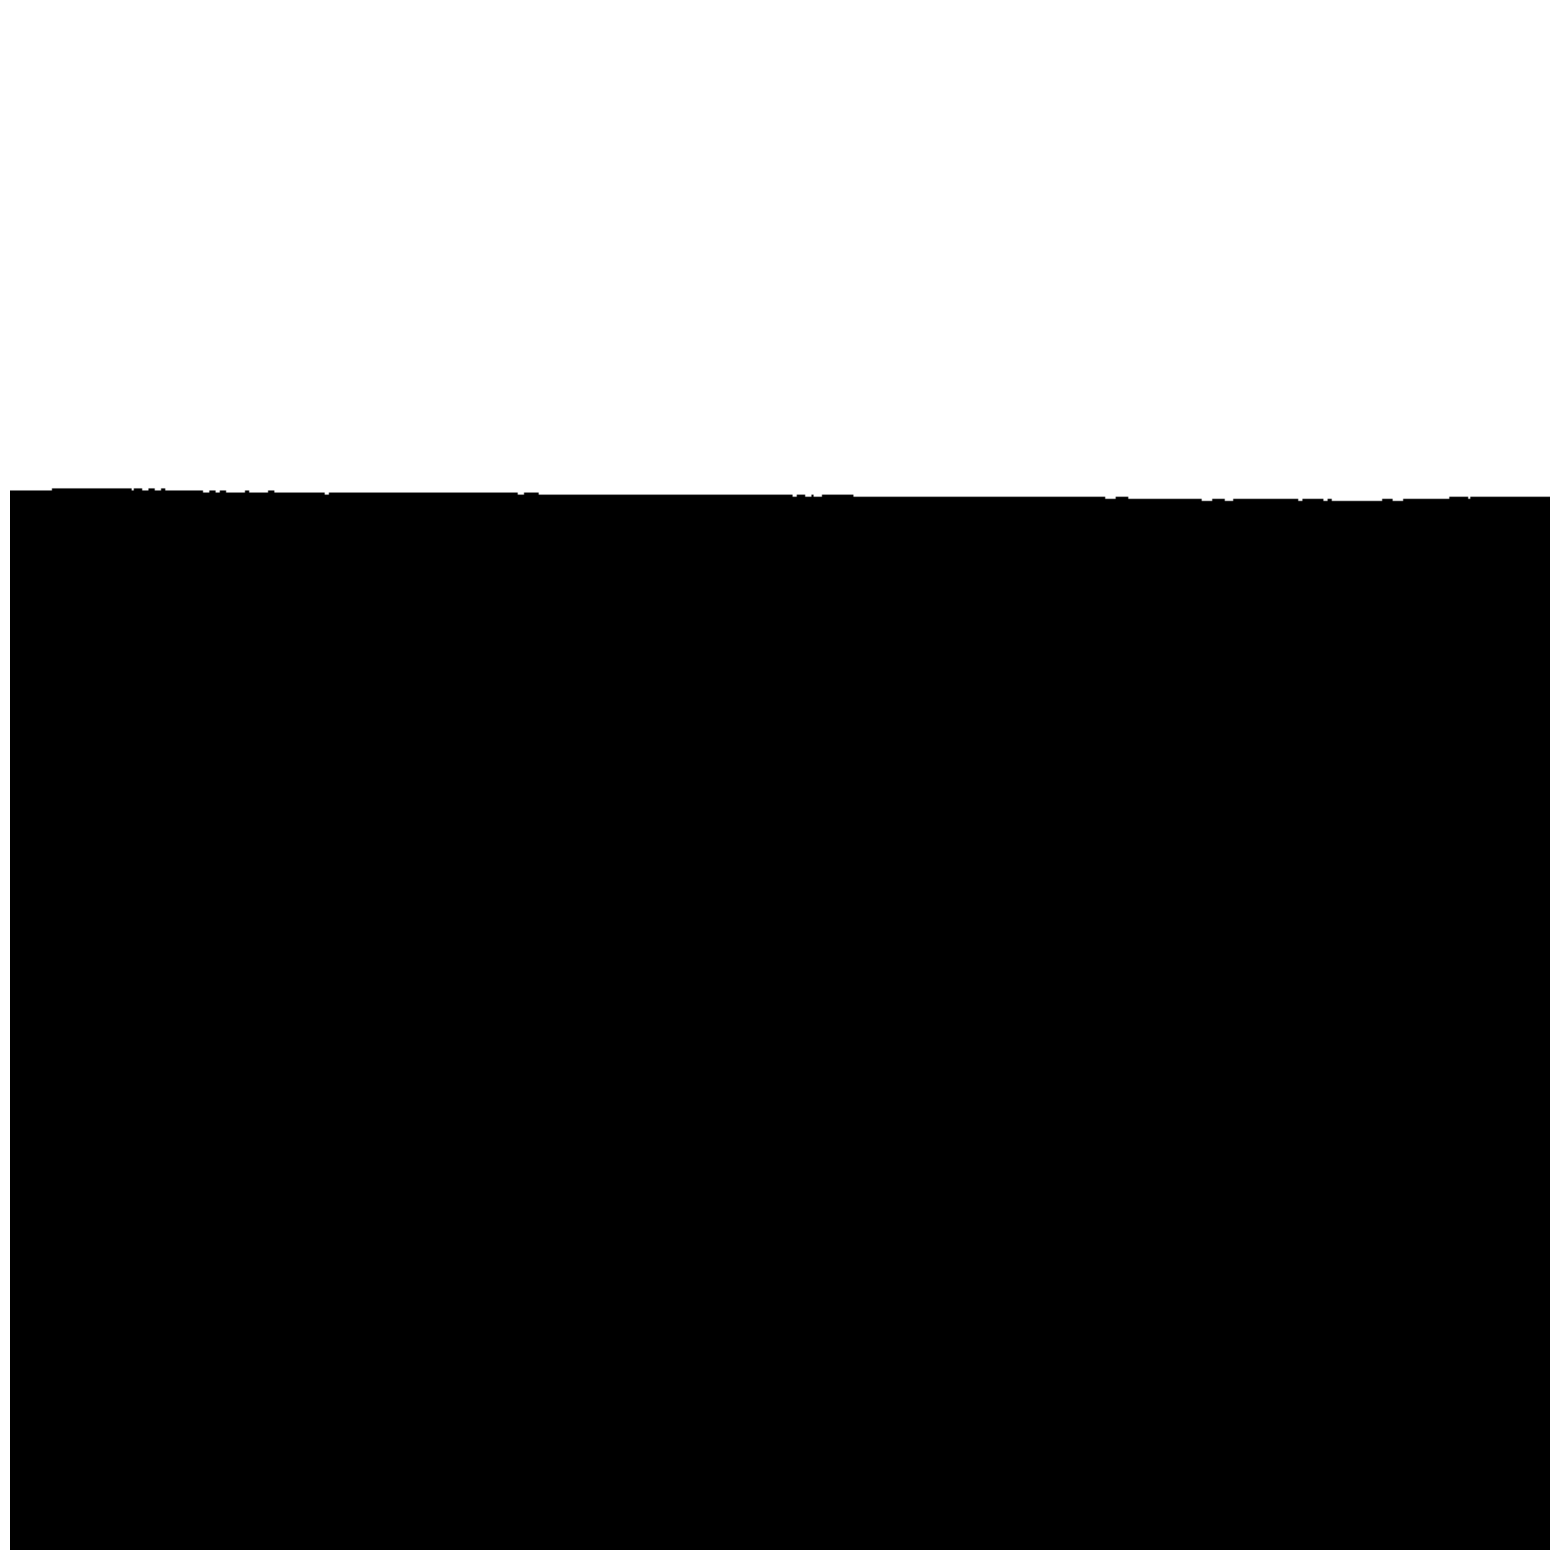

169699


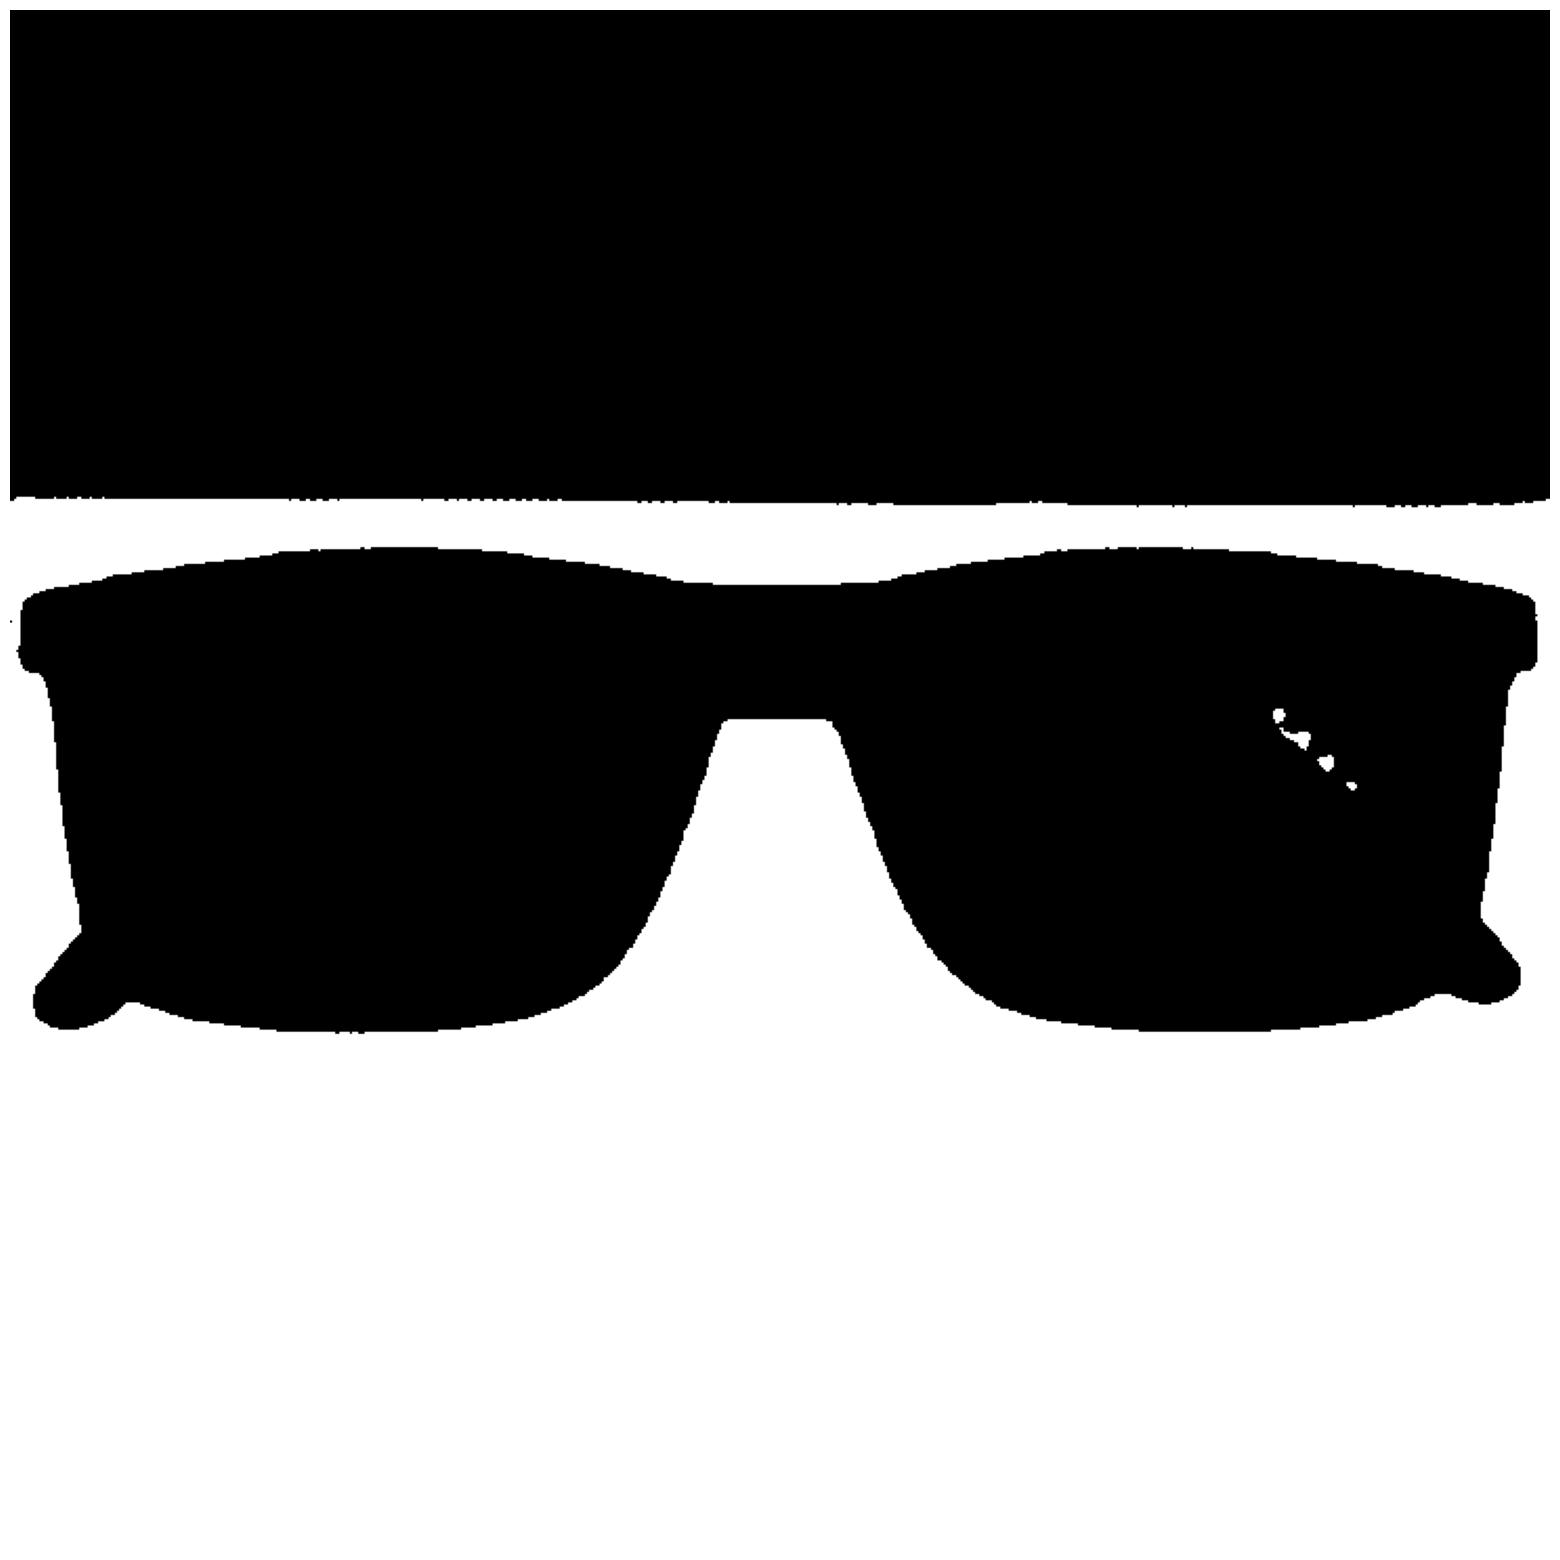

231587


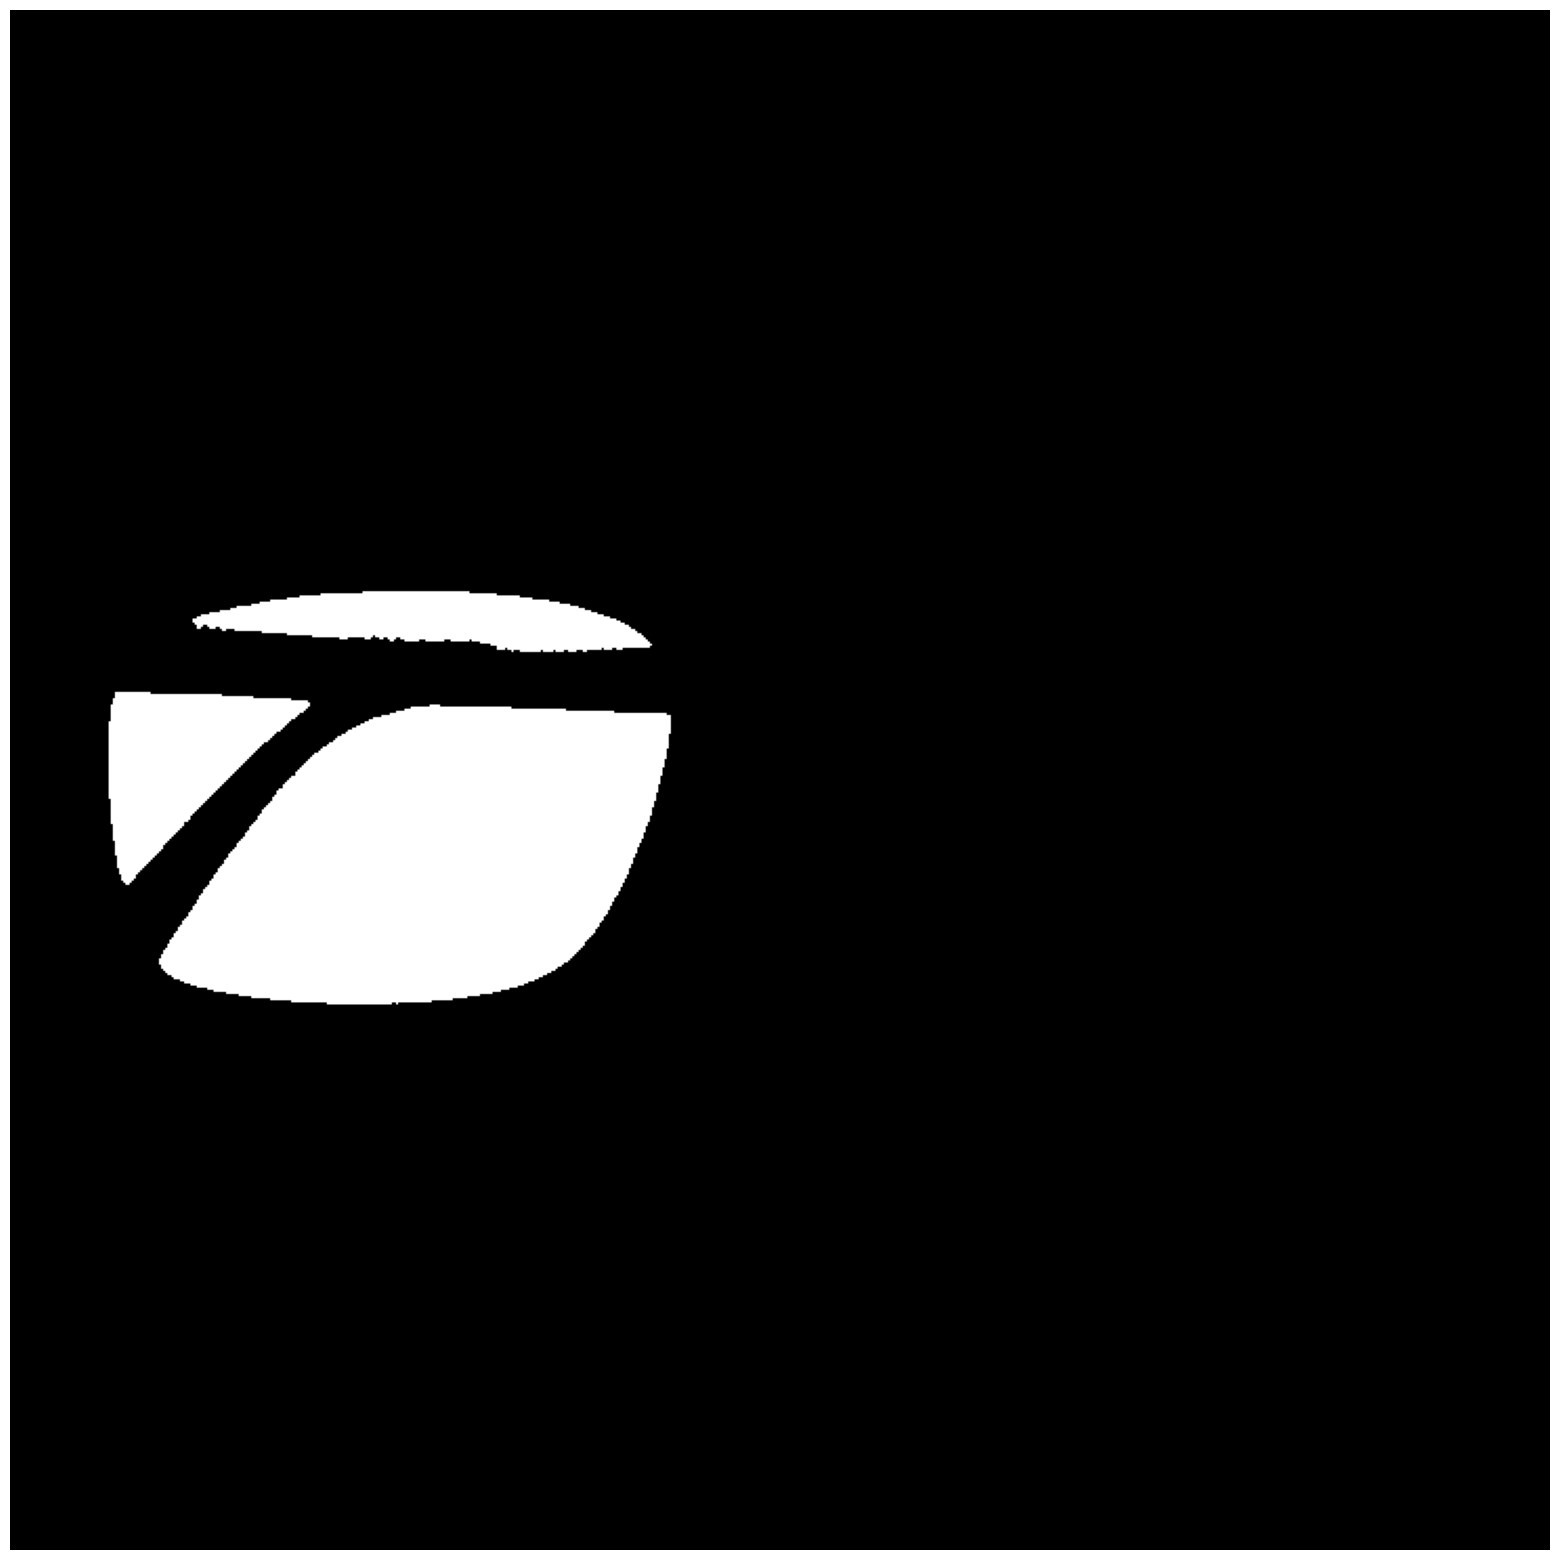

33902


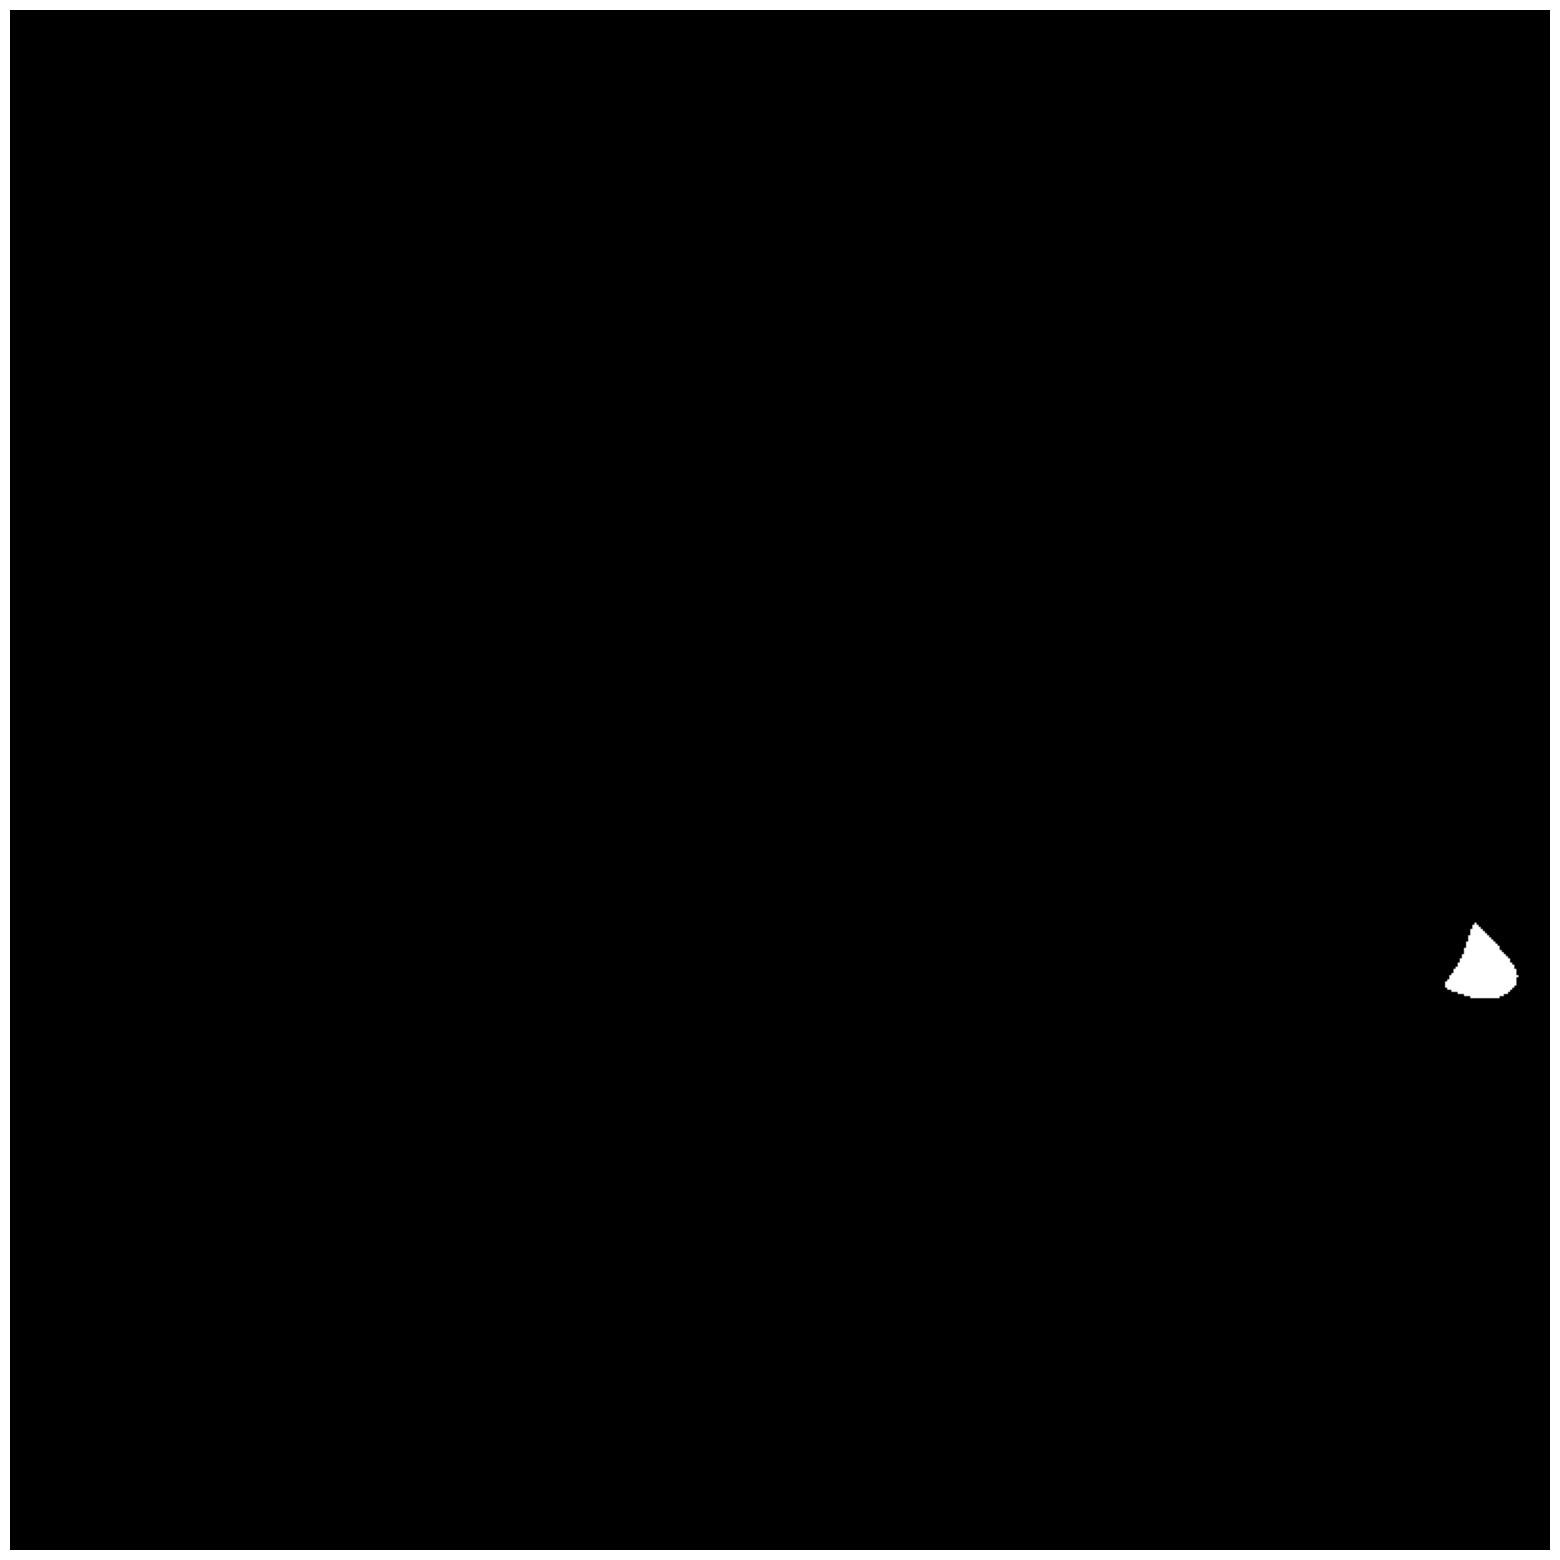

739


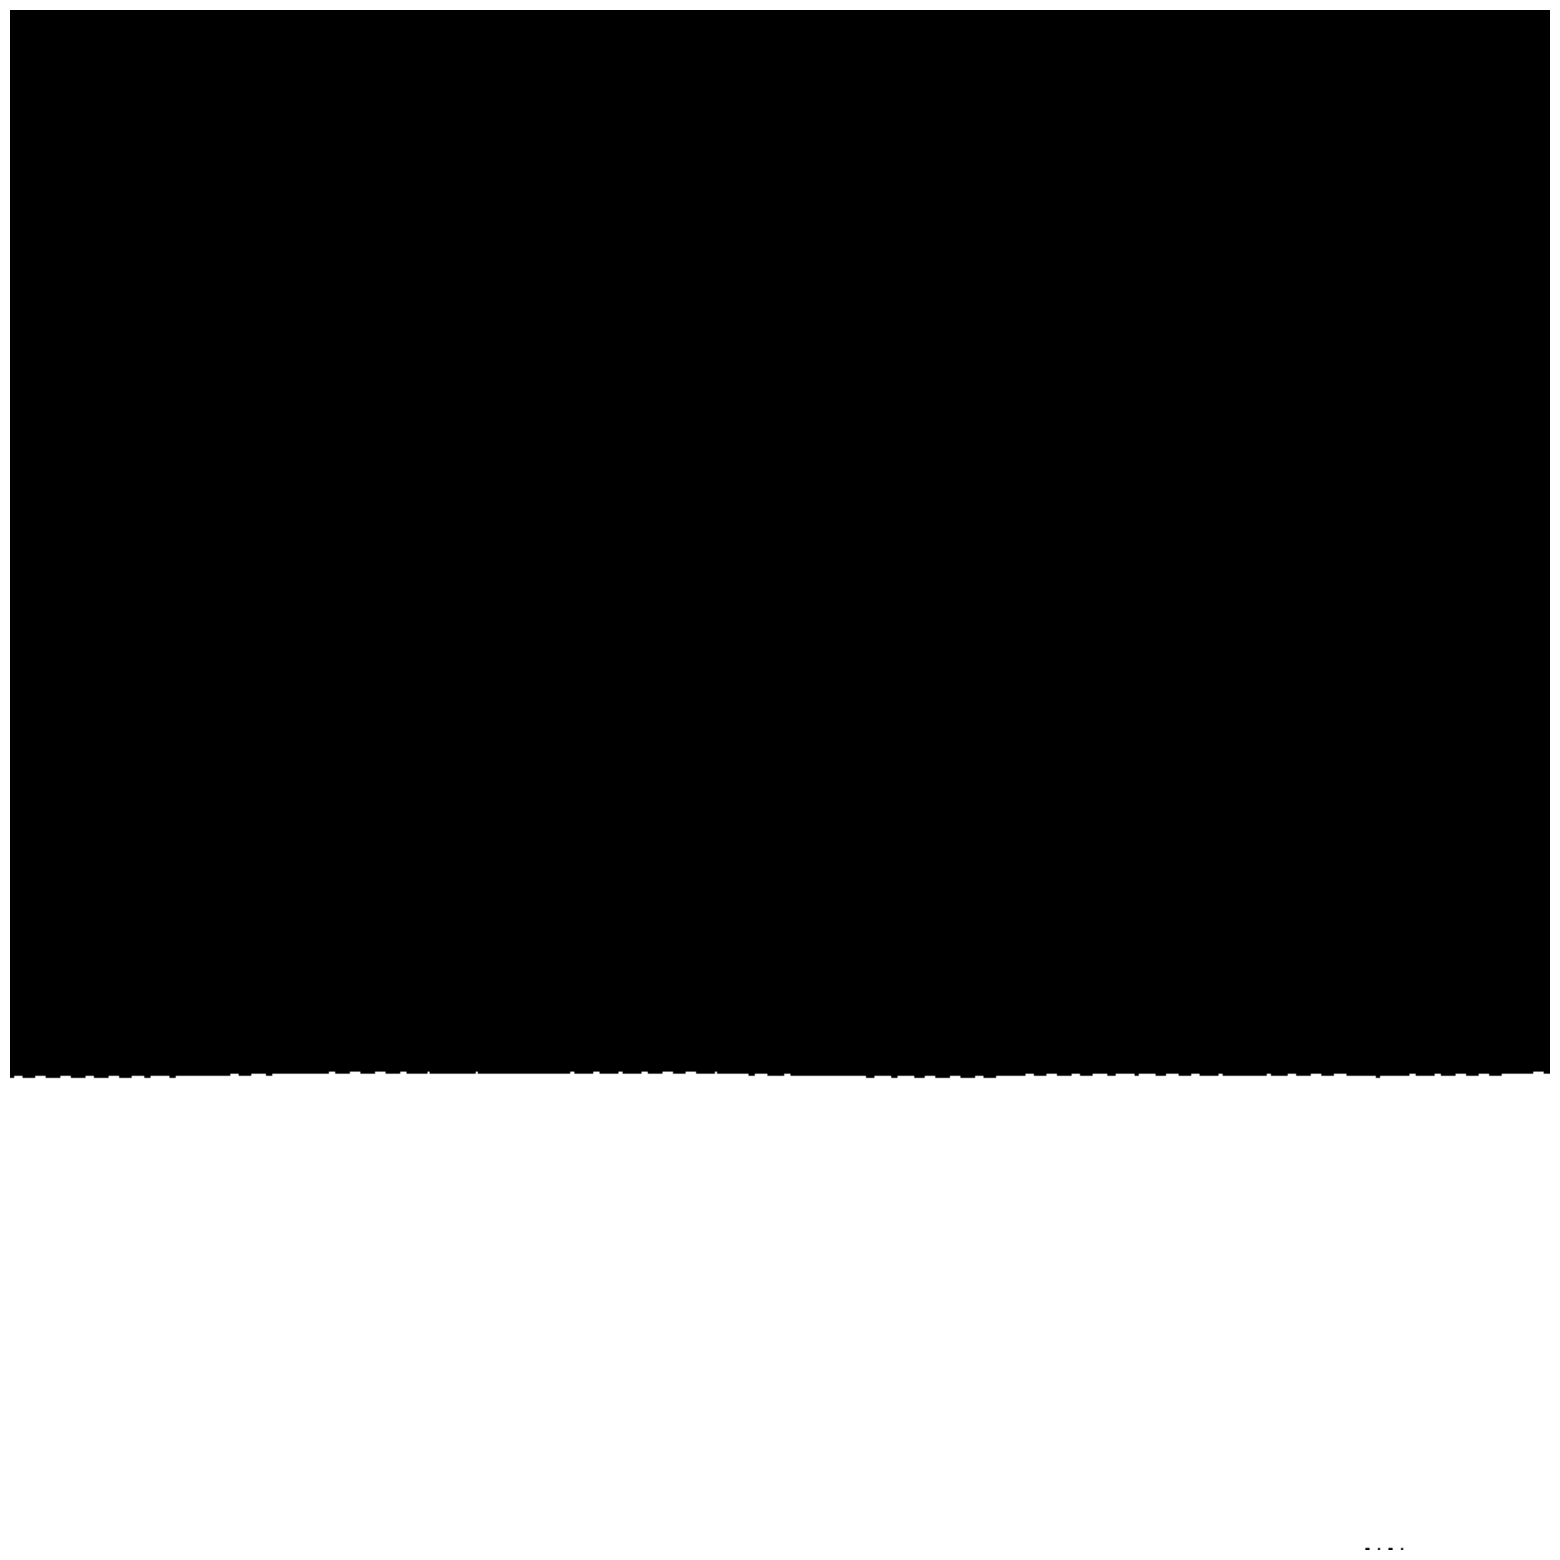

166199


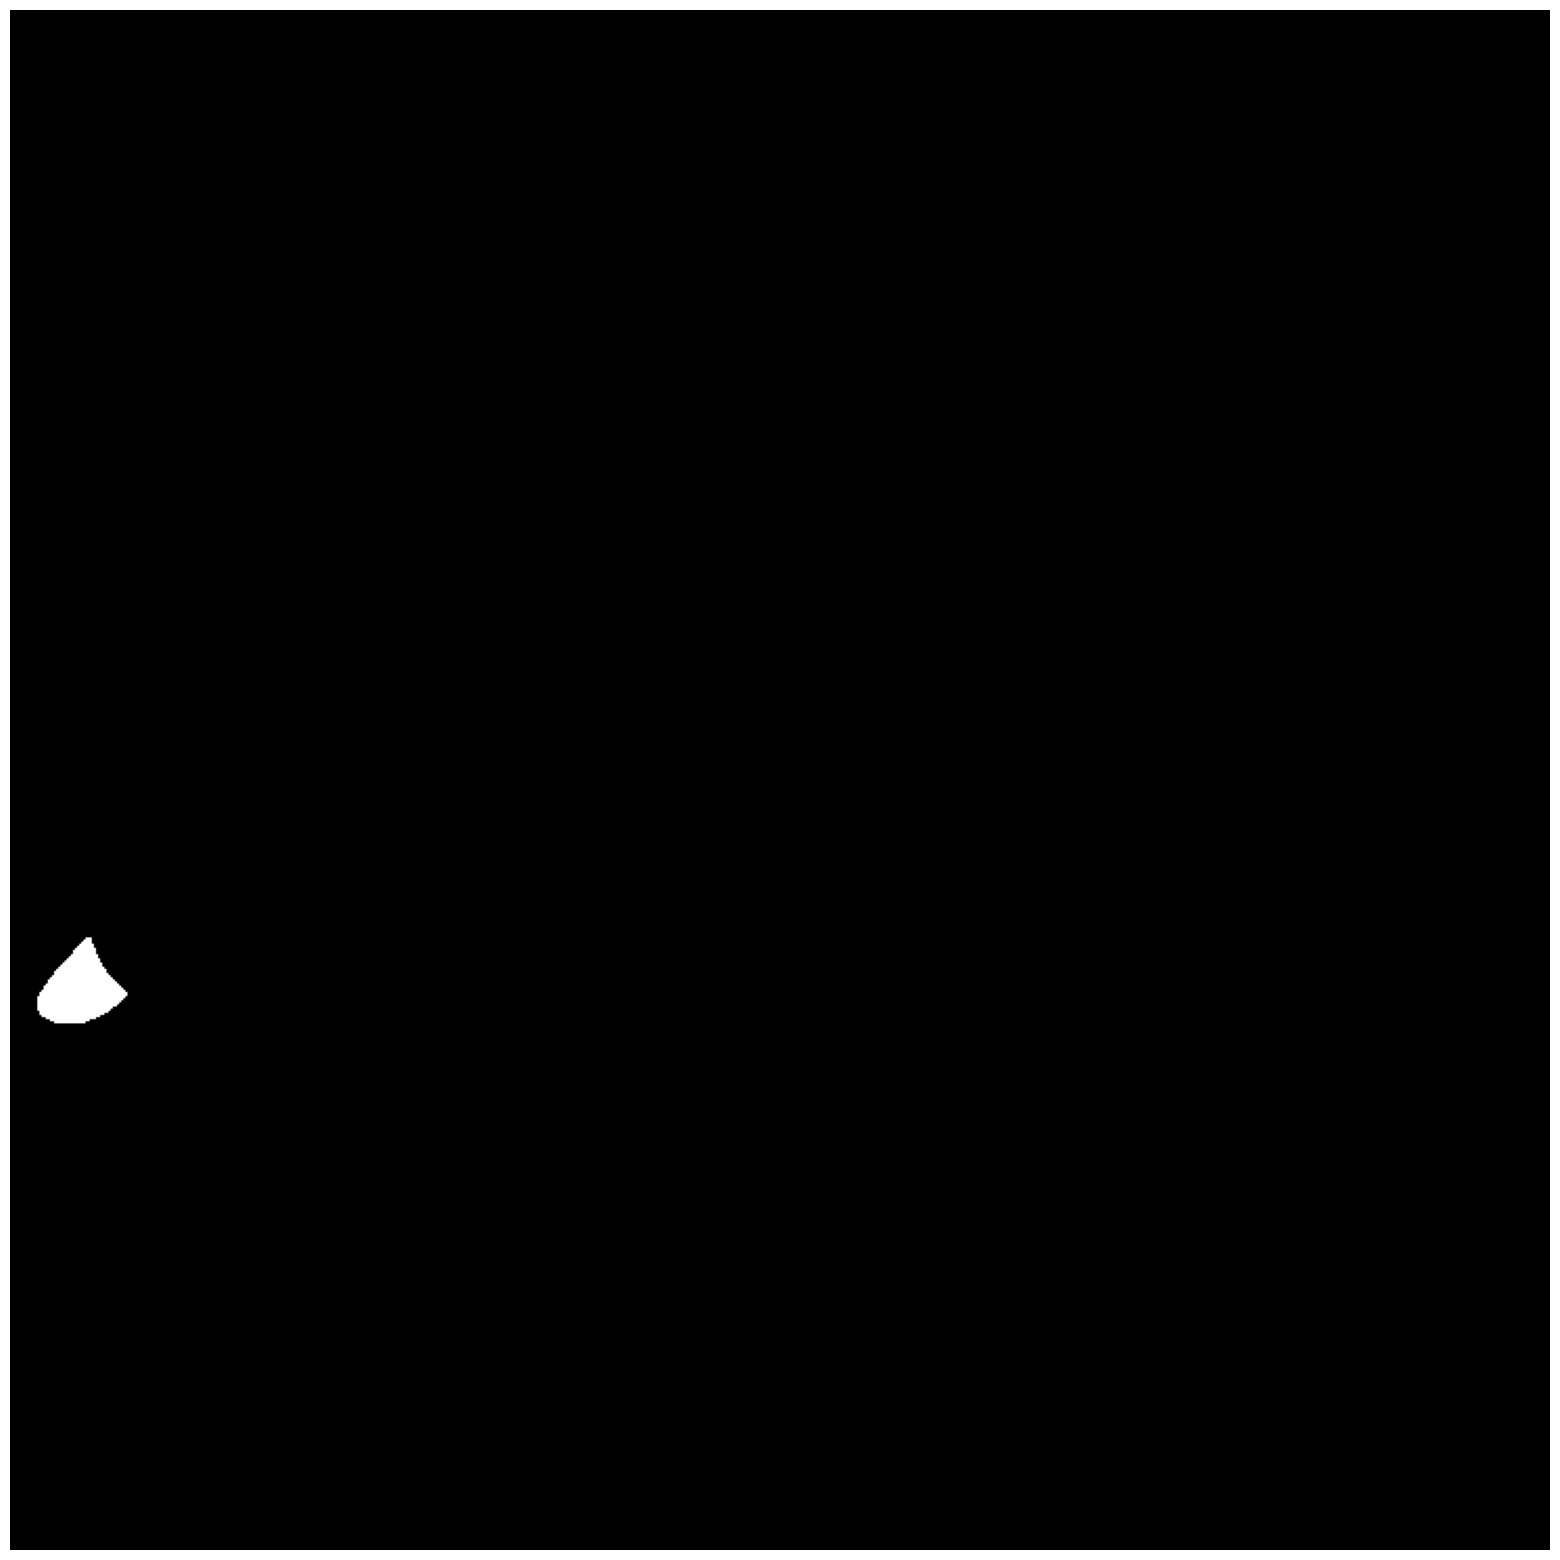

1033


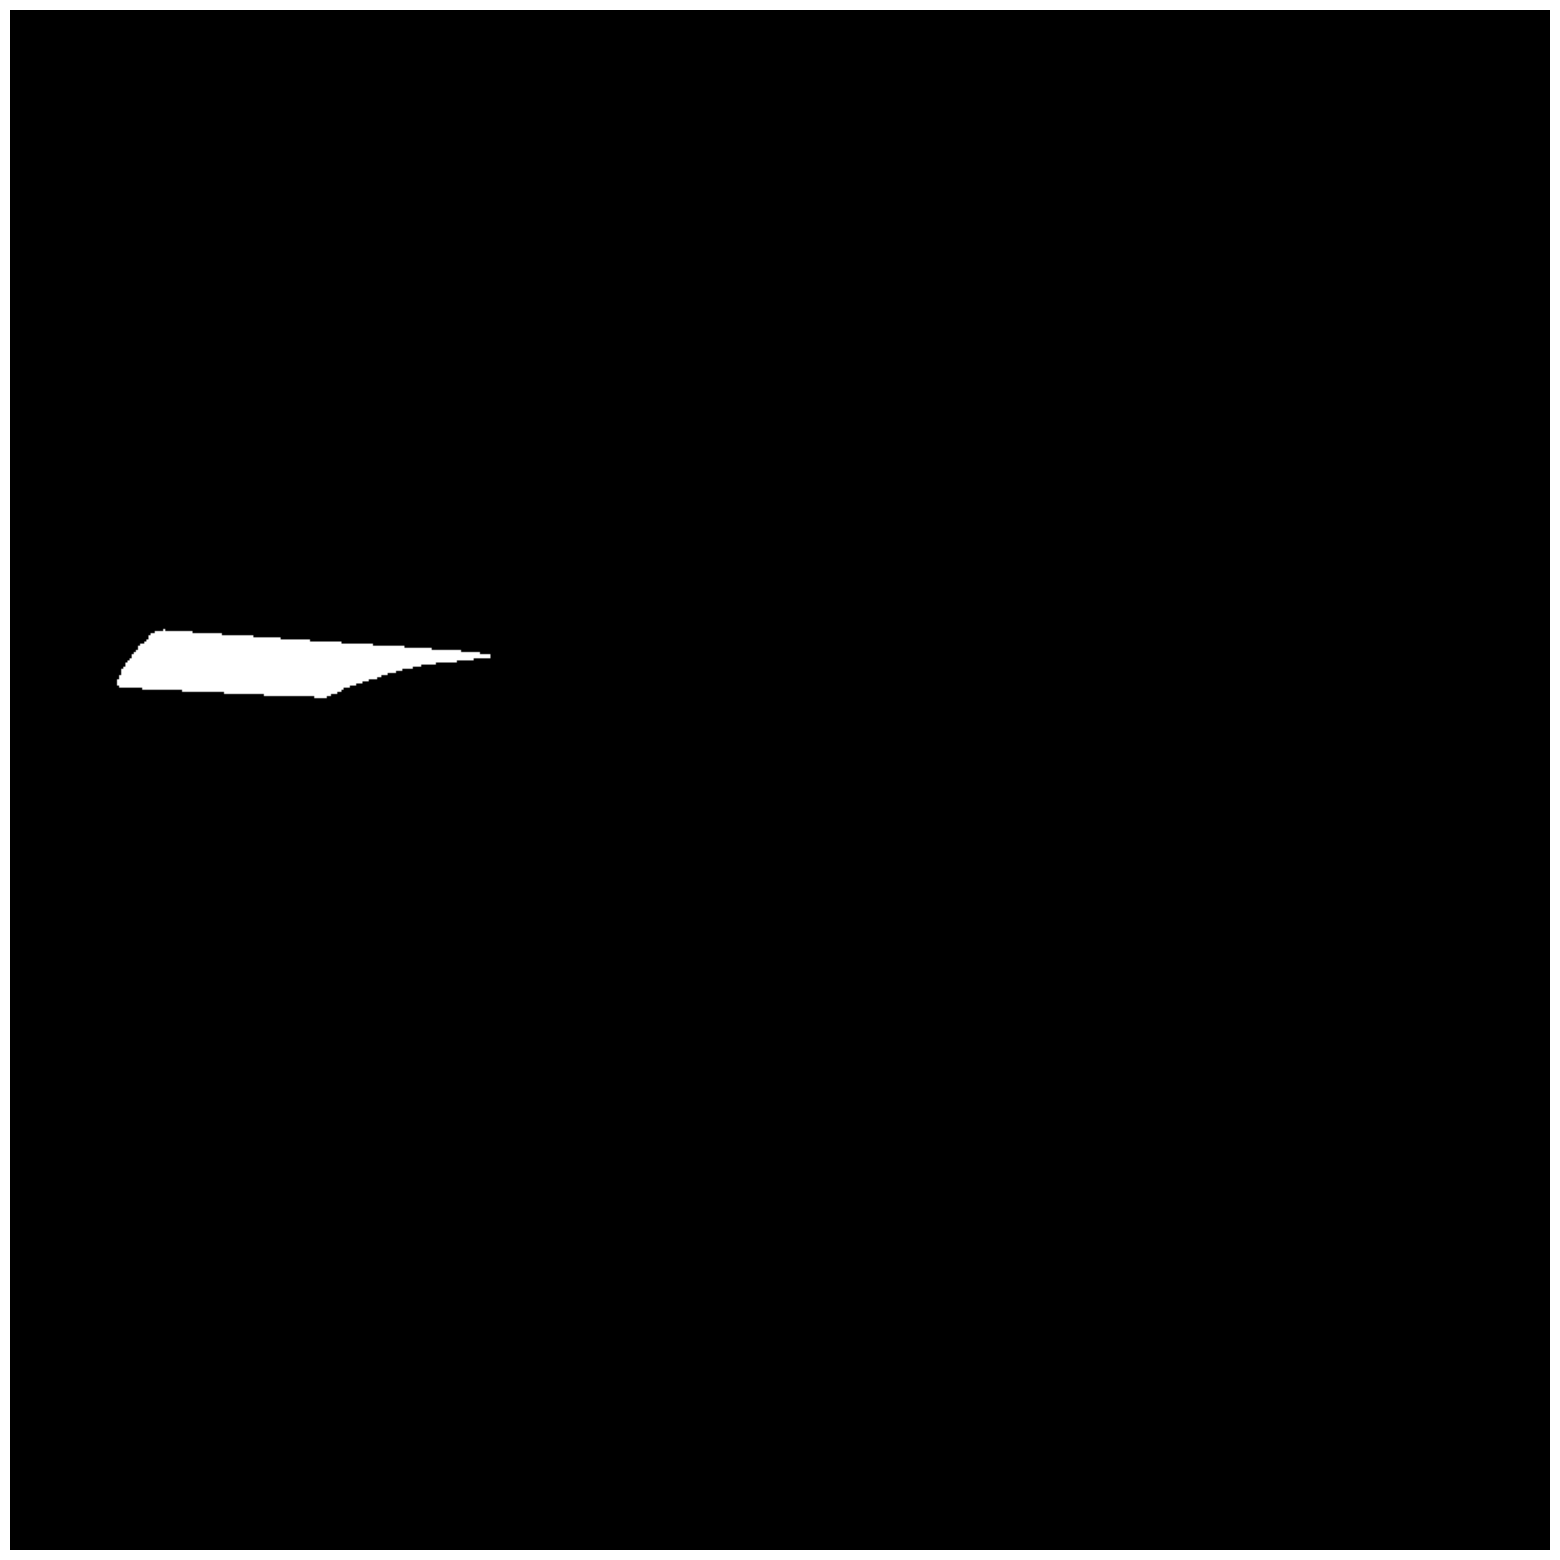

3491


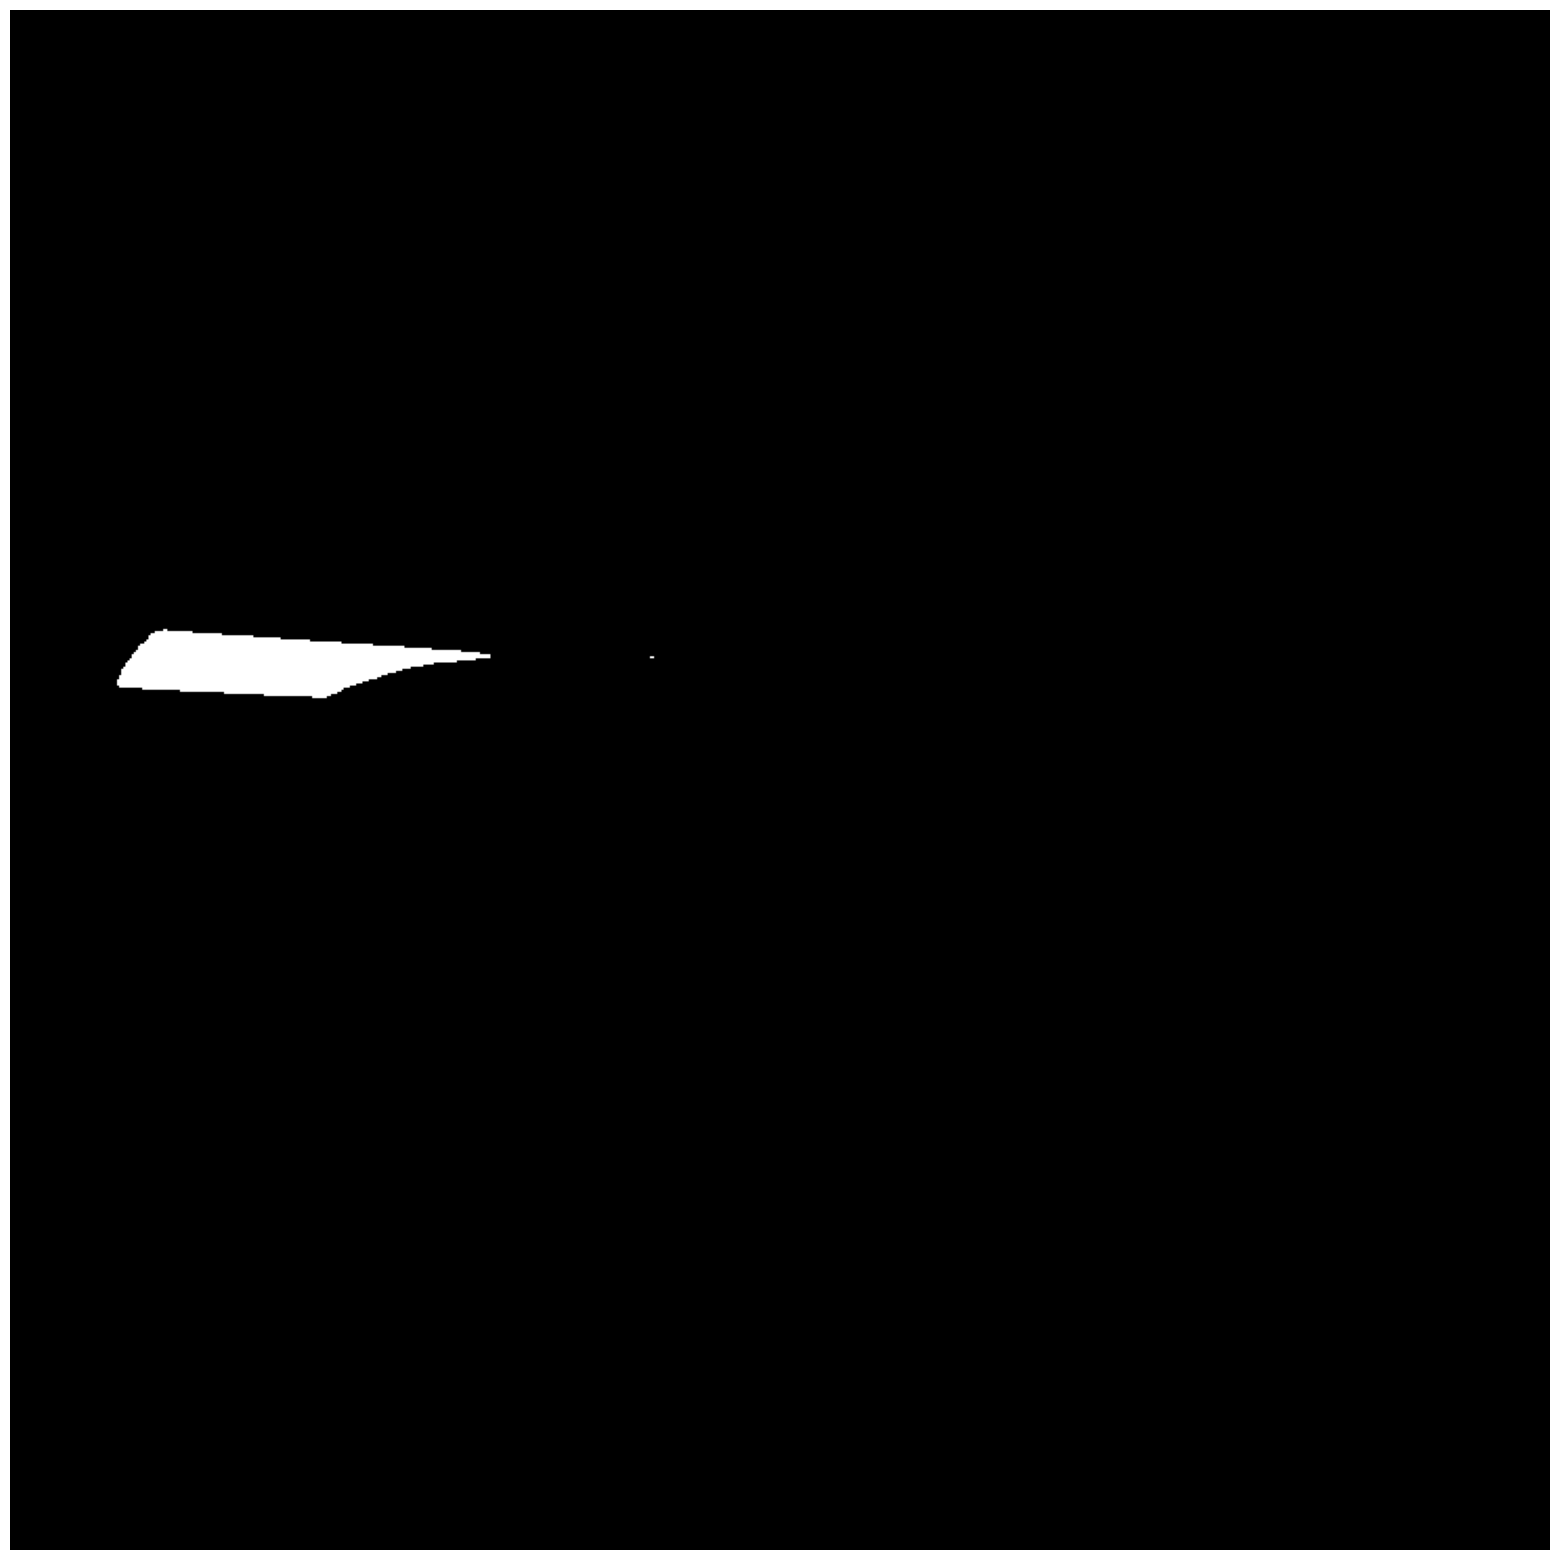

3496


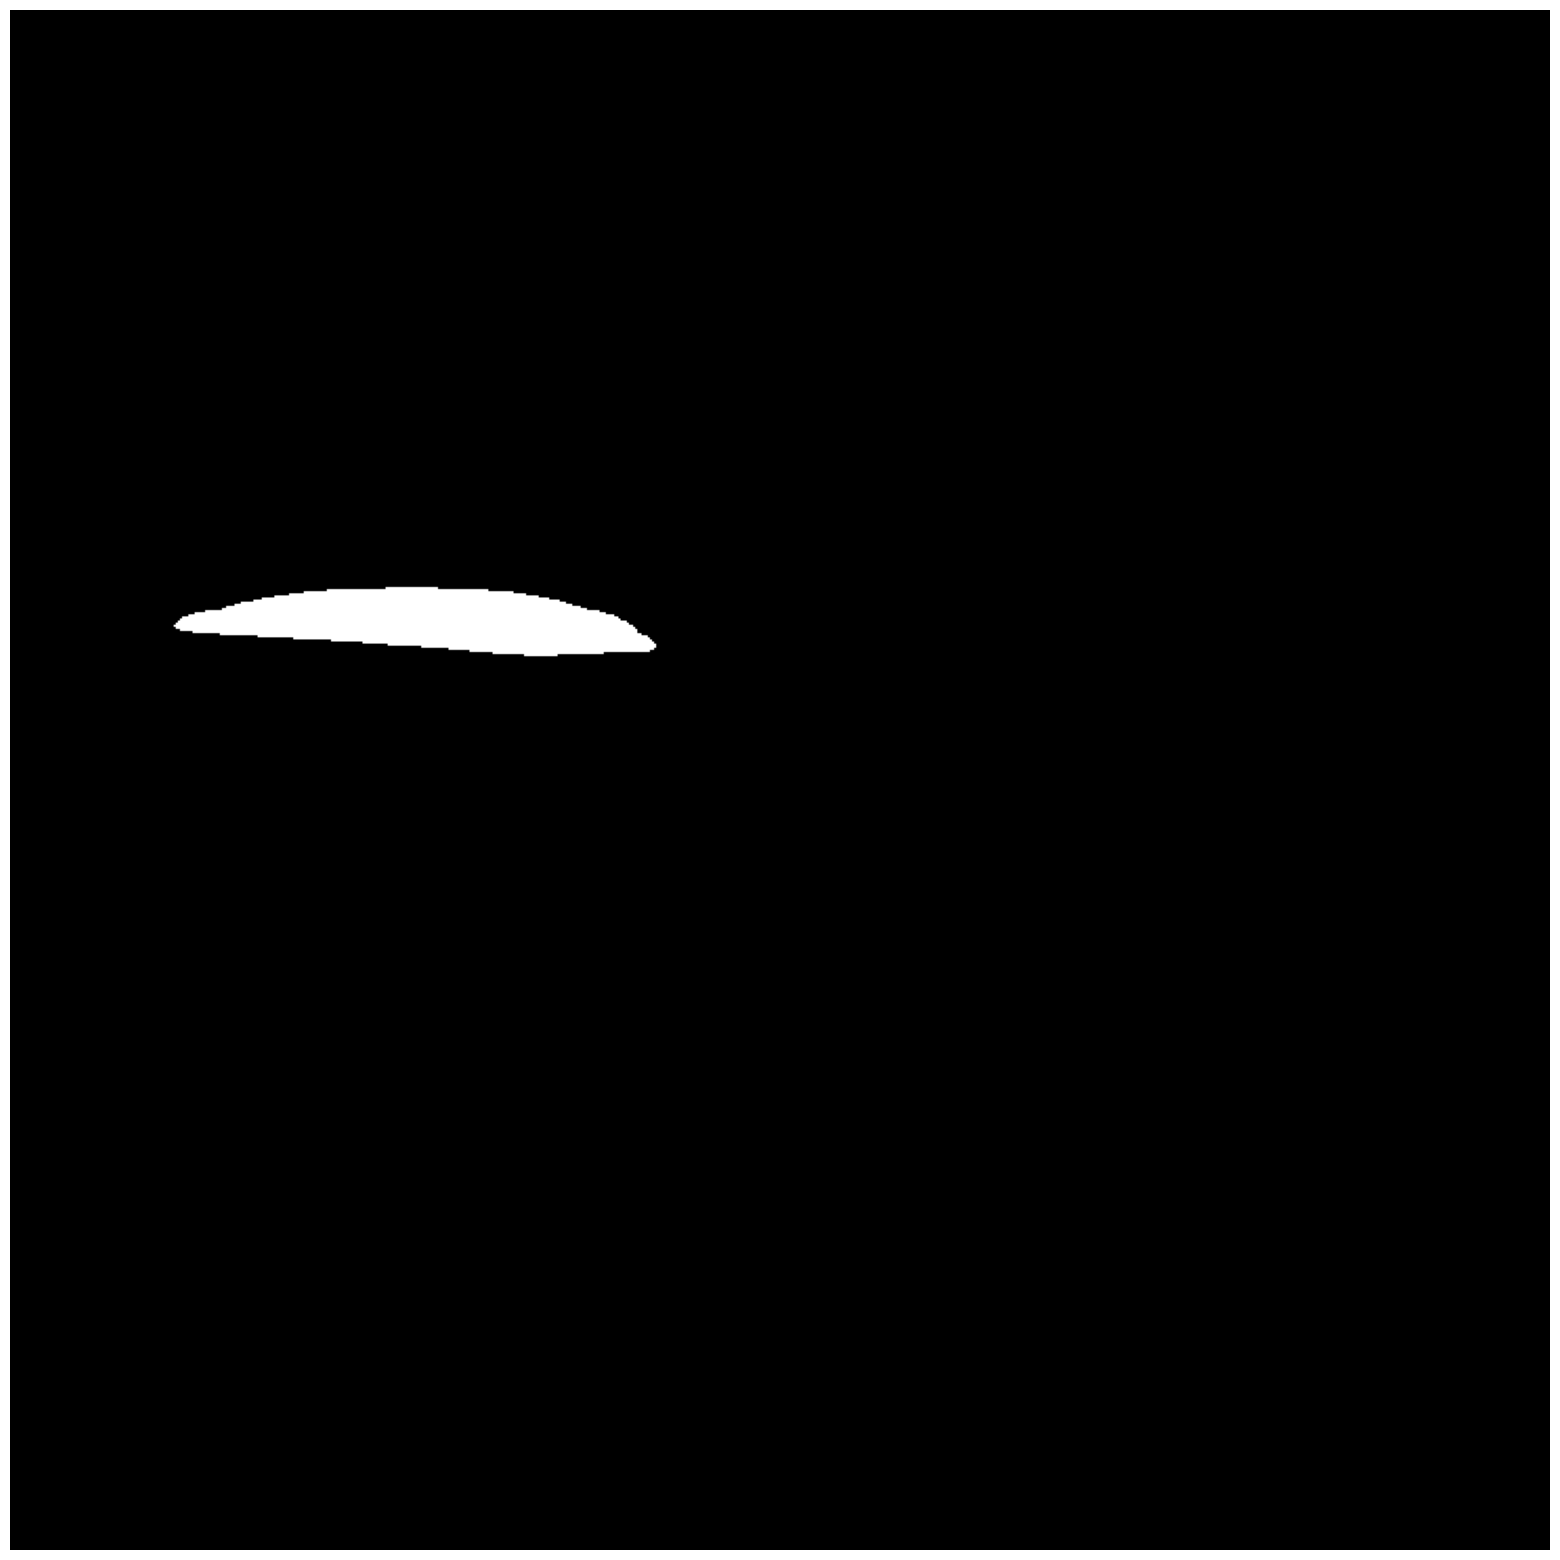

5028


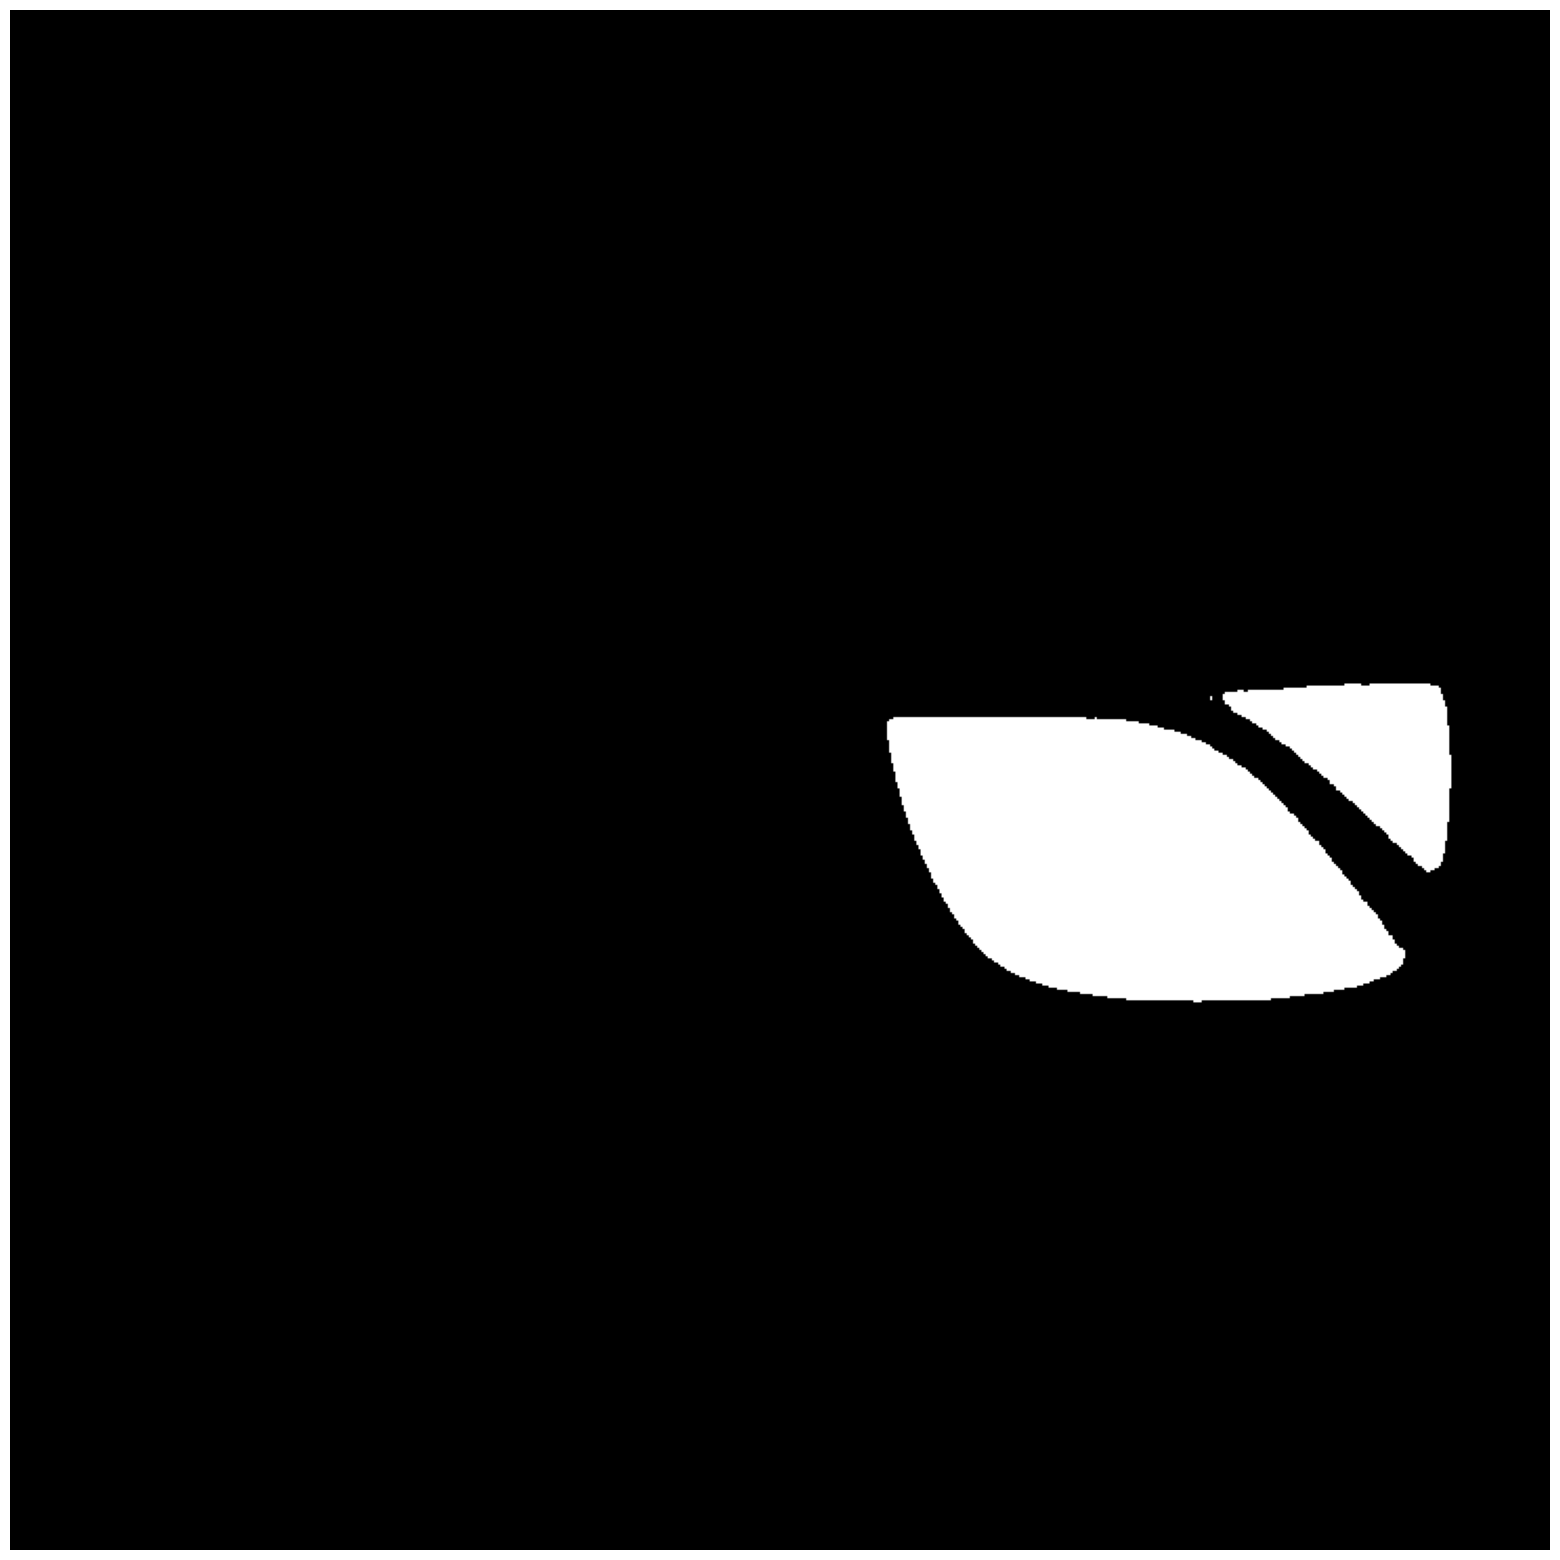

29316


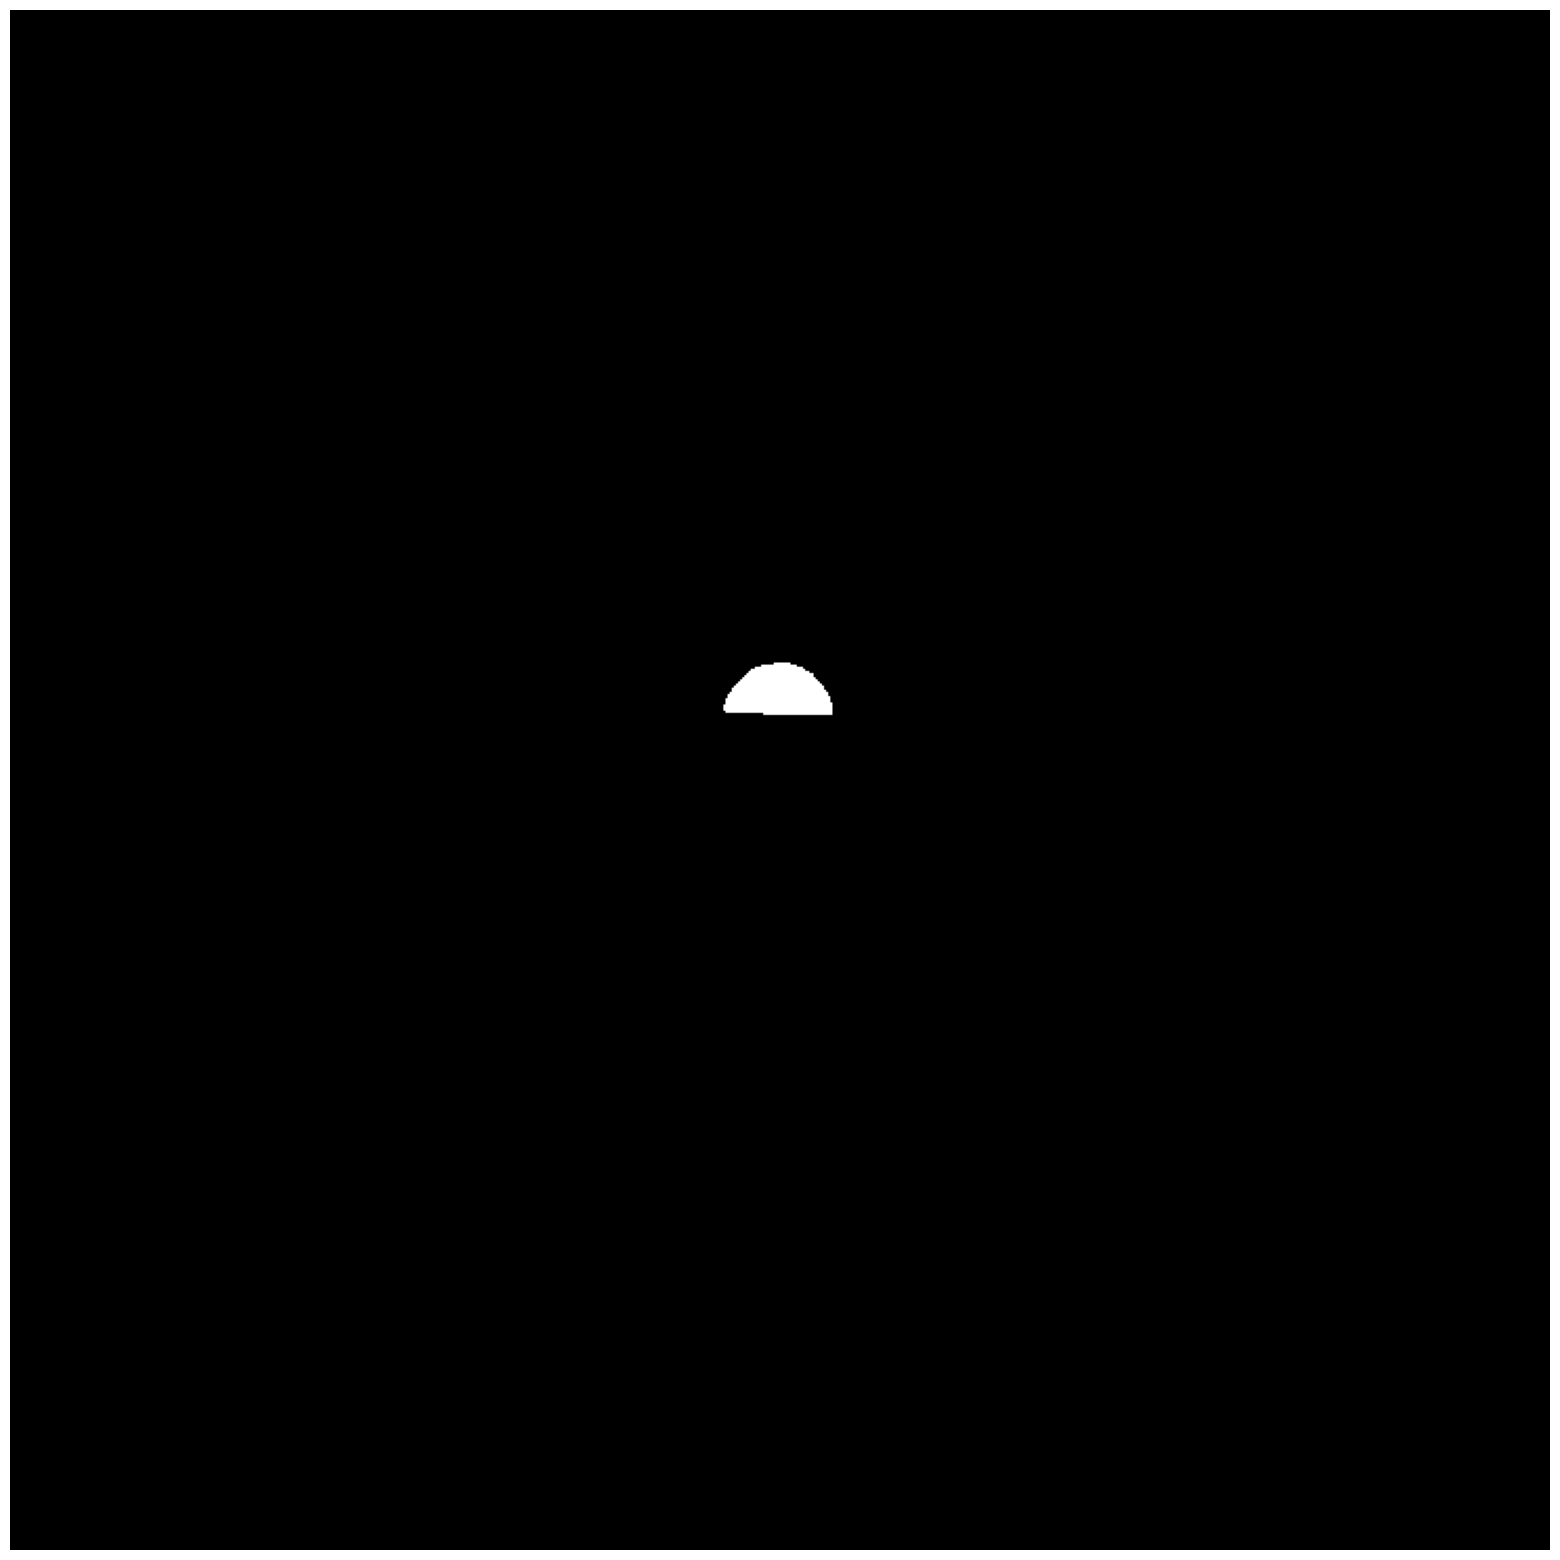

987


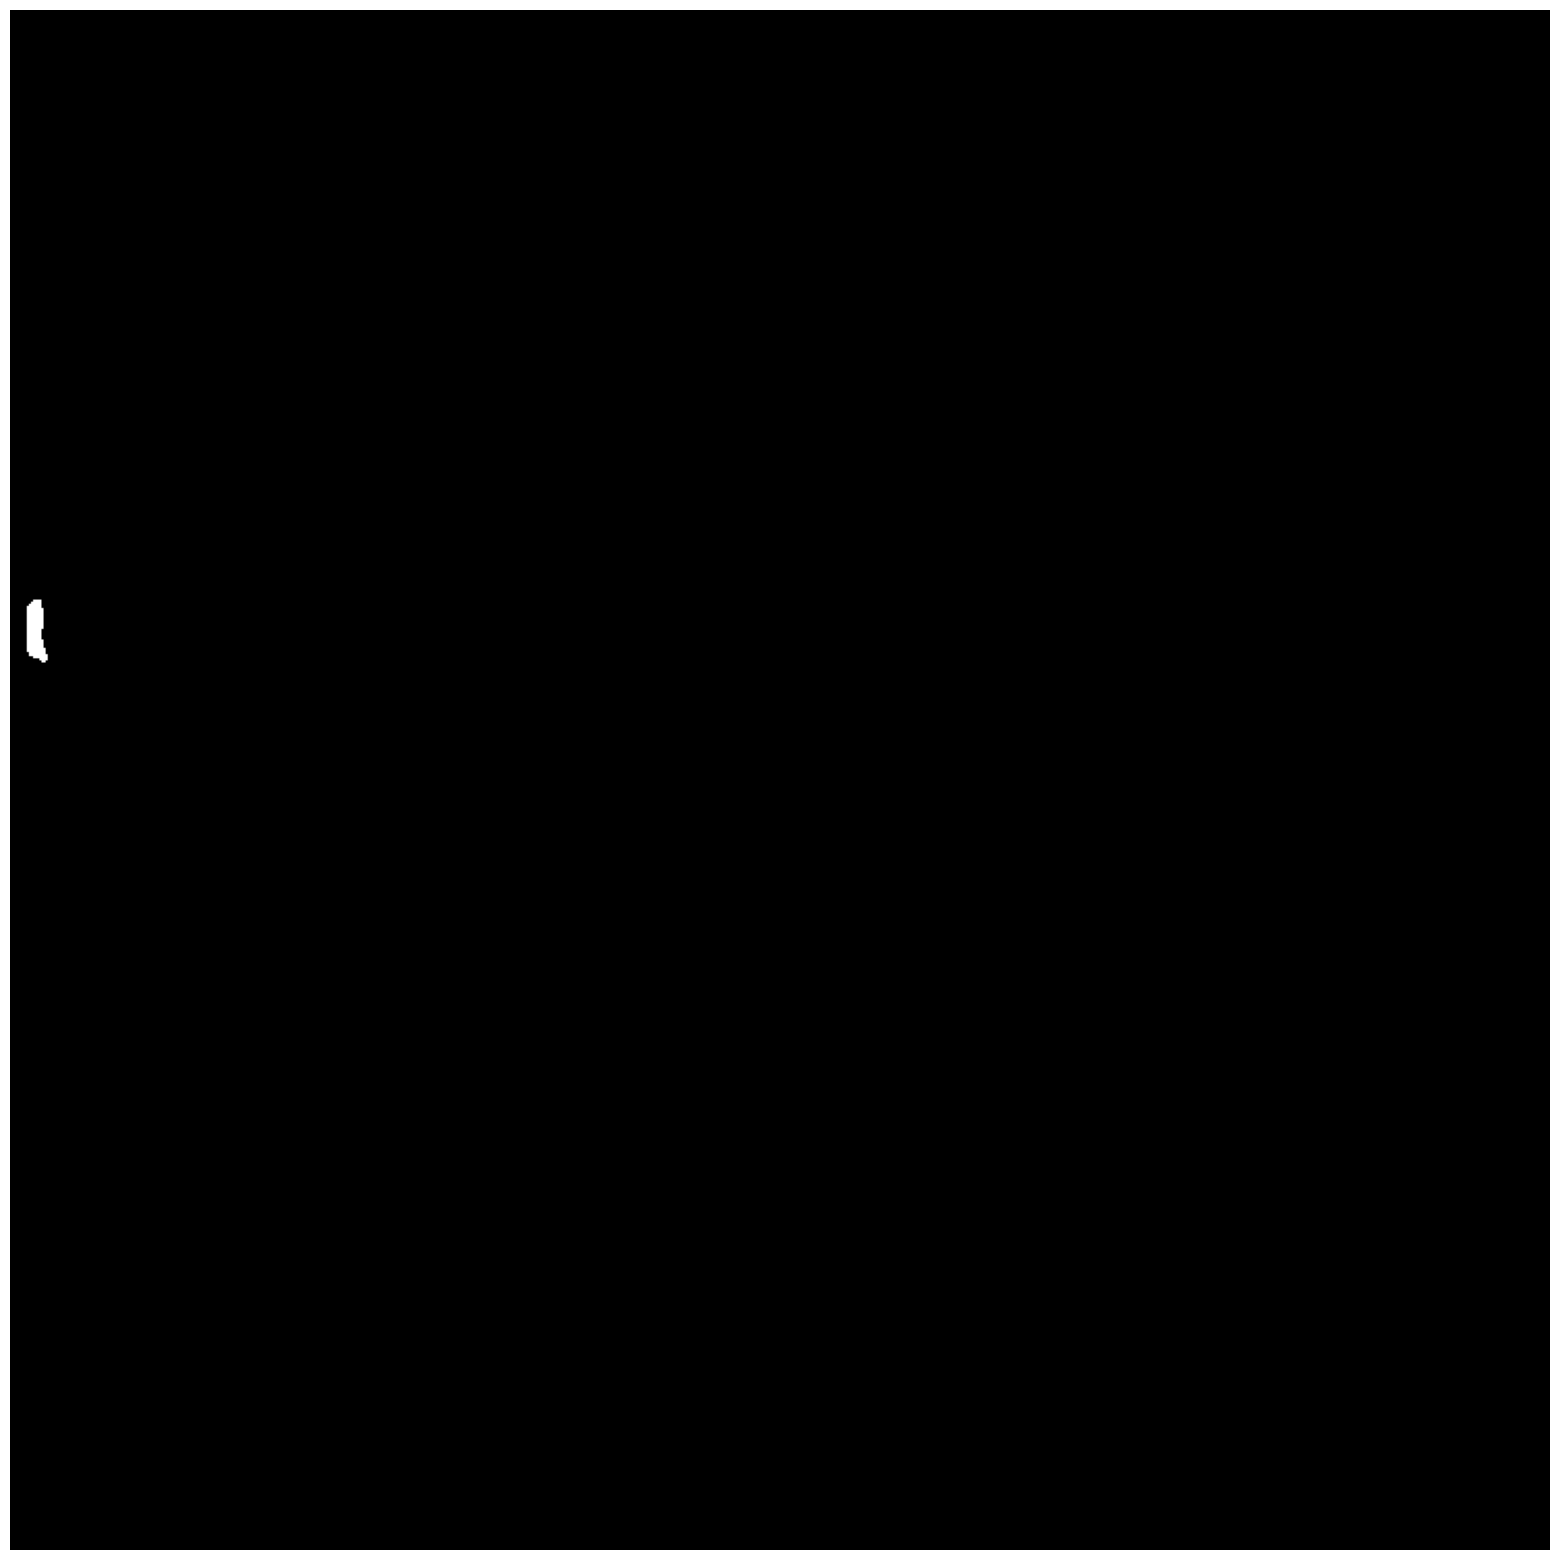

217


In [73]:
for mask in masks:
    plt.figure(figsize=(20, 20))
    
    # Access the 'segmentation' key to get the mask
    segmentation_mask = mask['segmentation']
    
    # Display the segmentation mask
    plt.imshow(segmentation_mask, cmap='gray')
    plt.axis('off')
    plt.show()
    print(mask['area'])

In [66]:
# Identify the mask with the largest area
eyeframe_mask = max(masks, key=lambda x: x['area'])

# Create a binary mask
binary_mask = eyeframe_mask['segmentation'].astype(np.uint8)

# Apply the mask to the image
result = cv2.bitwise_and(image, image, mask=binary_mask)

# Create a composite mask of all other masks
composite_mask = np.zeros_like(binary_mask)
for mask in masks:
    if mask is not eyeframe_mask:
        composite_mask = np.logical_or(composite_mask, mask['segmentation'])
        

composite_mask = composite_mask.astype(np.uint8)

# Invert the composite mask
inverted_composite_mask = cv2.bitwise_not(composite_mask * 255)

# Apply the inverted composite mask to the image to keep only the eyeframe
result = cv2.bitwise_and(result, image, mask=inverted_composite_mask)

# Save or display the result
cv2.imwrite('eyeframe_extracted.jpg', result)
plt.show('Eyeframe', result)


## CleanUp

In [ ]:
# Clean-up (doersn't work well, best option is approach taken by Photolayers, but I can't find any information about it)

from PIL import Image
import numpy as np

def remove_almost_white_pixels(image_path, threshold=170):
    # Load the image
    img = Image.open(image_path)

    # Convert image to numpy array for faster pixel manipulation
    img_np = np.array(img)

    # Define the threshold for almost white pixels (adjust as needed)
    # Threshold is the minimum value for any RGB channel to be considered as white
    mask = np.logical_or.reduce((img_np[:,:,0] > threshold,
                                 img_np[:,:,1] > threshold,
                                 img_np[:,:,2] > threshold))

    # Set almost white pixels to fully transparent (RGBA = [0, 0, 0, 0])
    img_np[mask] = [0, 0, 0, 0]

    # Convert numpy array back to image
    img_cleaned = Image.fromarray(img_np)

    return img_cleaned

# Example usage:
input_image_path = "masked_image.png"
cleaned_image = remove_almost_white_pixels(input_image_path)
cleaned_image.save("cleaned_image.png")  # Save the cleaned image


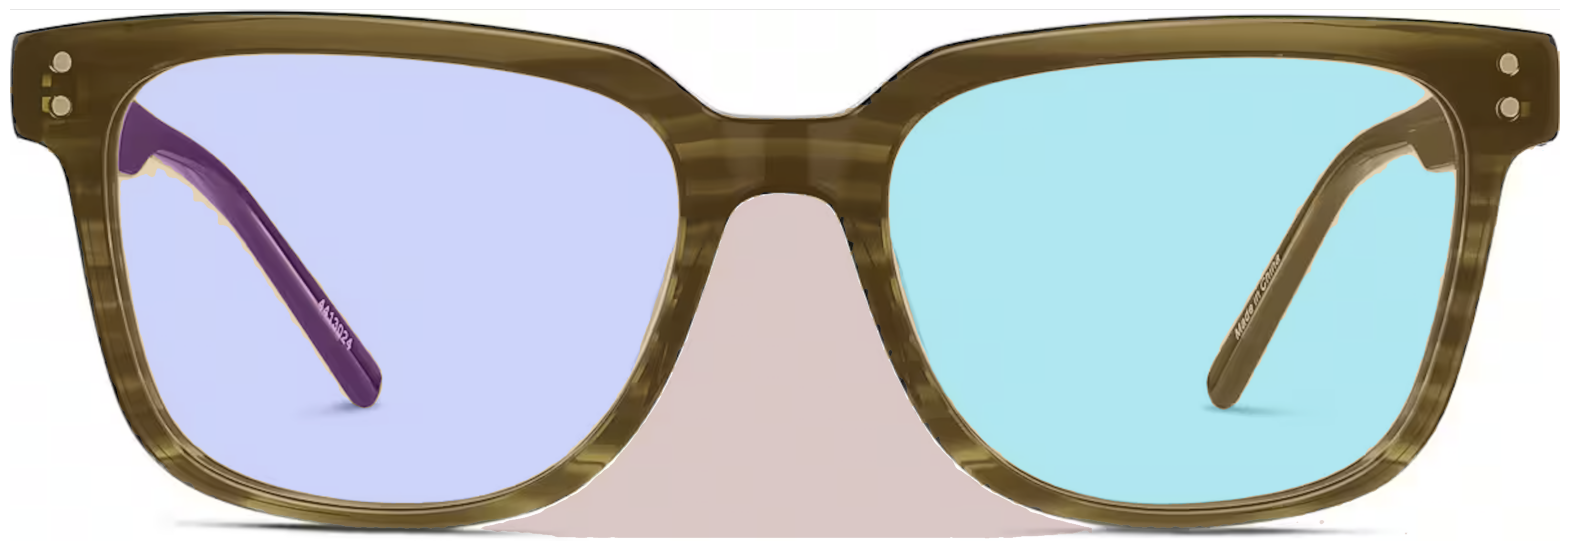

In [26]:
# display detected masks

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [24]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,  # Assuming 'sam' is your segmentation model
    points_per_side=64,  # Increase for finer detail
    pred_iou_thresh=0.8,  # Lower to include more predictions
    stability_score_thresh=0.9,  # Higher for more stable masks
    crop_n_layers=2,  # Increase for multi-level refinement
    crop_n_points_downscale_factor=4,  # Adjust based on detail needed
    min_mask_region_area=500,  # Increase to filter out small regions
)

In [25]:
masks2 = mask_generator_2.generate(image)

In [26]:
len(masks2)

28

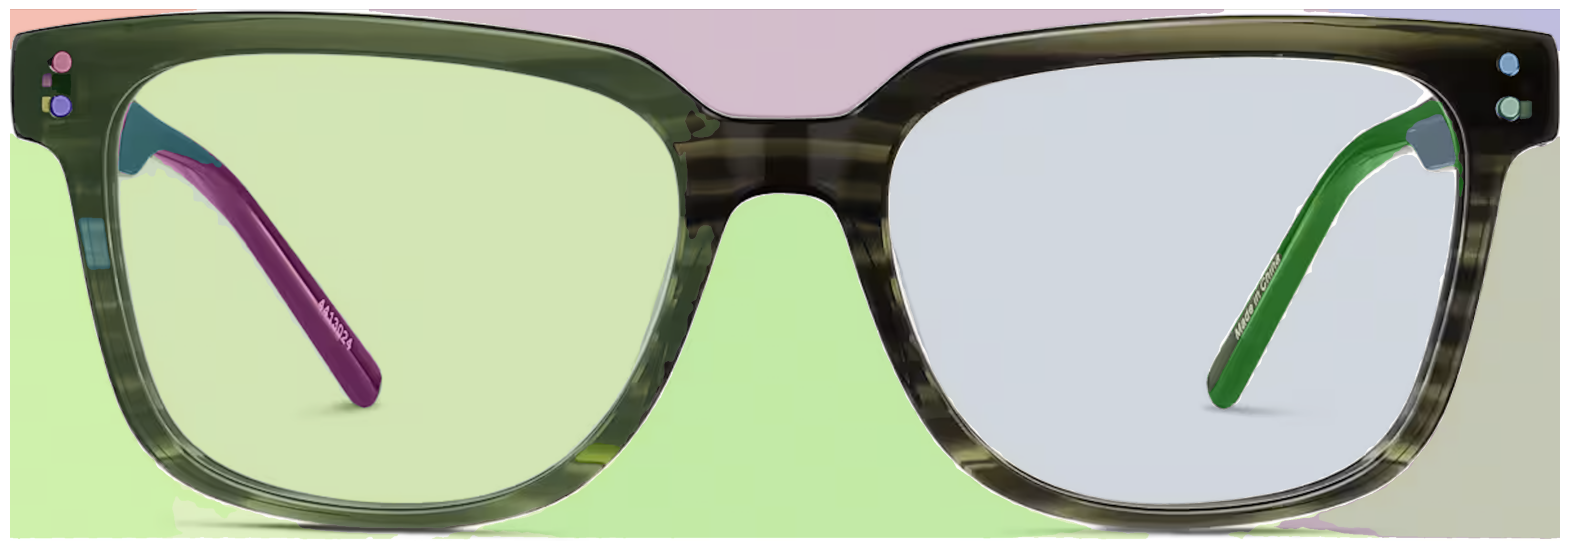

In [27]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show()

In [25]:
import sys
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the model
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda"  # Use CPU
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Create a mask generator
mask_generator = SamAutomaticMaskGenerator(sam)

# Load and preprocess the images
image_paths = ["images/gaparota.jpg", ]
images = [Image.open(image_path).convert("RGB") for image_path in image_paths]
images_np = [np.array(image) for image in images]

# Function to generate masks for each image
def generate_masks(mask_generator, image_np):
    masks = mask_generator.generate(image_np)
    return masks

# Generate and visualize masks
for i, image_np in enumerate(images_np):
    masks = generate_masks(mask_generator, image_np)

    plt.figure(figsize=(10, 10))
    plt.imshow(image_np)

    if isinstance(masks, list) and len(masks) > 0:
        for mask in masks:
            if "segmentation" in mask:  # Check if 'segmentation' key exists
                plt.imshow(mask["segmentation"], alpha=0.5)
    else:
        print(f"No masks found for image {i+1}")

    plt.title(f"Segmented Image {i+1}")
    plt.axis('off')
    plt.show()


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

## Postprocessing image

In [49]:
# removes detected masks from the image, leaving just front part of eyeframe

from PIL import Image
import numpy as np

def remove_masks(image_path, masks):
    # Load the original image
    original_image = Image.open(image_path).convert("RGBA")
    width, height = original_image.size

    # Create an array to hold the result
    result_image = np.array(original_image)

    # Iterate over each mask and clear the corresponding area in result_image
    for mask in masks:
        if "segmentation" in mask:
            # Assuming mask["segmentation"] is a binary mask where True indicates the area to be masked
            binary_mask = mask["segmentation"].astype(bool)

            # Set the masked area in result_image to transparent
            result_image[binary_mask] = [0, 0, 0, 0]  # RGBA: Transparent

    # Convert result_image back to Image object
    result_image = Image.fromarray(result_image)

    # Save or return the result image (depending on your needs)
    return result_image

# Example usage:
# Assuming masks is generated by mask_generator.generate(image)
image_path = "images/test01.png"
masked_image = remove_masks(image_path, masks)
masked_image.save("masked_image.png")  # Save the resulting image